# The Shape of a Molecule
### Can Graph Structure Alone Predict Quantum Behavior?

---

A density functional theory (DFT) calculation on a single small organic molecule takes hours on a university computing cluster. The QM9 dataset (130,831 molecules with 19 quantum mechanical properties each) costs thousands+ of CPU hours to produce. If a cheap graph algorithm running in seconds on a laptop could reproduce those numbers with acceptable accuracy, we would have a powerful speedup for drug screening, organic photovoltaic design, and materials discovery.

This notebook asks: **how much of a molecule's quantum behavior is encoded in its graph topology alone?**

We pursue that research question through three rounds of methods varying in complexity, with the HOMO-LUMO energy gap as the single target property. The reason for the selection of the HOMO-LUMO gap as our quantum property is more in depth discussed afterwards, but a quick rundown is that it is useful for generally determining a material's strength/conductivity/behavior; additionally, it is considered due to the applicability with graphs since a common naive approach to this quantum property is "The denser a cell, the potential for a smaller gap". Hence, round one of the three rounds uses nothing but atom counts as a baseline and for the answer to the naive approach. Round two adds hand-crafted graph-mining features (ring structure, community detection, centrality measures) drawn from the data mining course curriculum. Round three trains a GINEConv (a graph neural network with edge-aware message passing) that learns its own features from the raw molecular graph. Between rounds two and three, a brief interlude asks whether graph mining can *rediscover* known chemical structure without any chemical labels.

The answer is revealing, and the gap between rounds two and three tells us exactly what classical graph mining cannot see.



## Table of Contents

1. [Background: what is the HOMO-LUMO gap?](#background)
2. [Setup](#setup)
3. [Meeting the Data — EDA](#eda)
4. [Q0 — The Composition Floor (atom-count baseline)](#q0)
5. [Q1 — The Graph-Mining Tour (course techniques)](#q1)
   - [Q1a — Rings and Motifs](#q1a)
   - [Q1b — Louvain Community Detection](#q1b)
   - [Q1c — Centrality and PageRank](#q1c)
   - [Q1d — Combined Ridge Model and Results](#q1d)
6. [Interlude — Does Graph Mining Rediscover Chemistry?](#interlude)
7. [Q2 — The GINEConv Challenger (external technique)](#q2)
8. [Q3 — A Tour of QM9 in Four Molecules (case studies)](#q3)
9. [Failed Experiments](#failures)
10. [Takeaways, Limitations, and Future Work](#takeaways)
11. [Honor Statement and Citations](#honor)

<a id='background'></a>
## 1. Background: What Is the HOMO-LUMO Gap?

Every molecule has a set of molecular orbitals. The **HOMO** (Highest Occupied Molecular Orbital) is the outermost electron shell, it is the highest-energy orbital that is actually occupied by electrons. The **LUMO** (Lowest Unoccupied Molecular Orbital) is the lowest-energy orbital that has no electrons in it yet. The **gap** between them (measured in electron-volts, eV) is one of the most important single numbers in computational chemistry.

A large gap means the molecule is chemically inert, it needs a large energy kick to do anything interesting. A small gap means the molecule readily absorbs light, conducts electricity, or reacts with other molecules. This makes the HOMO-LUMO gap the key screening criterion for:
- **Organic photovoltaics**: small-gap molecules absorb more sunlight.
- **Drug design**: gap controls reactivity and binding affinity.
- **Semiconductor materials**: gap separates insulators from conductors.

In QM9, all 19 properties, including the gap, were computed by running DFT at the B3LYP/6-31G(2df,p)**\*** level on each molecule \**(NOTE: These complex letters basically just detail the physics computational setup)*. That level of theory gives results accurate enough for materials screening, but it is computationally expensive. Our question is whether a model that only *looks at the graph*, without any quantum simulation, can approximate the same answer.

**The QM9 dataset.** QM9 contains 130,831 stable, neutral, singlet-state organic molecules drawn from chemical universe database GDB-17. Each molecule has up to 9 heavy atoms drawn from {C, O, N, F} with H filling out valence. Every molecule is provided as a graph: atoms are nodes (with atomic number and coordinates), bonds are edges (with bond-type labels). We use PyTorch Geometric's built-in loader, which handles the preprocessing.

**Our central question, made precise:** Given only the graph topology of a molecule (atom types + bond types, no 3D coordinates, no quantum orbitals), what is the best MAE we can achieve on the HOMO-LUMO gap? and how does that vary between classical feature engineering and learned graph representations?

<a id='setup'></a>
## 2. Setup

In [4]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx
import torch
import torch.nn.functional as F
from torch_geometric.utils import to_networkx
from rdkit import Chem, RDLogger
from rdkit.Chem import Draw, AllChem, GetSSSR
import community as cm
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import adjusted_rand_score
from IPython.display import display
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
RDLogger.logger().setLevel(RDLogger.CRITICAL)

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.dpi'] = 110

Device: cuda


In [5]:
from load_qm9 import load_qm9_dataset

DATA_DIR = os.path.abspath('qm9_data')
os.makedirs(DATA_DIR, exist_ok=True)

print("Loading QM9 dataset (downloads ~300 MB on first run)...")
dataset = load_qm9_dataset(root=DATA_DIR)
N = len(dataset)
print(f"Loaded {N:,} molecules.")
print(f"Example molecule: {dataset[0]}")

Loading QM9 dataset (downloads ~300 MB on first run)...
Loaded 130,831 molecules.
Example molecule: Data(x=[5, 11], edge_index=[2, 8], edge_attr=[8, 4], y=[1, 19], pos=[5, 3], z=[5], smiles='[H]C([H])([H])[H]', name='gdb_1', idx=[1])


<a id='eda'></a>
## 3. Meeting the Data

Before any modeling, we need a clear picture of what QM9 looks like. The dataset has some structural constraints that will shape everything that follows: molecules are small (at most 9 heavy atoms), the atom palette is narrow (only C, H, O, N, F), and all molecules are stable and neutral. NOTE: These are *design* constraints, and not bugs. The QM9 was built to be a systematic benchmark, not a random sample of chemistry.

The most important plot in this section is the HOMO-LUMO gap distribution, the rest are simply for interesting dataset observations.

In [6]:
# ---- Basic per-molecule statistics ----
ATOM_SYMBOLS = {1: 'H', 6: 'C', 7: 'N', 8: 'O', 9: 'F'}
GAP_IDX = 4  # HOMO-LUMO gap is target index 4 in QM9
TARGET_NAMES = ['mu','alpha','homo','lumo','gap','r2','zpve','U0','U','H','G','Cv']

num_atoms   = np.array([d.num_nodes for d in dataset])
num_heavy   = np.array([(d.z > 1).sum().item() for d in dataset])
atomic_nums = torch.cat([d.z for d in dataset]).numpy()
gaps        = np.array([d.y[0, GAP_IDX].item() for d in dataset])

print(f"Molecules:          {N:>10,}")
print(f"Atoms per molecule: {num_atoms.mean():.1f} avg  (range {num_atoms.min()}–{num_atoms.max()})")
print(f"Heavy atoms:        {num_heavy.mean():.1f} avg  (max 9)")
print(f"HOMO-LUMO gap:      {gaps.mean():.3f} eV avg  (std {gaps.std():.3f}, range {gaps.min():.3f}–{gaps.max():.3f})")

# Atom-type counts
vals, cnts = np.unique(atomic_nums, return_counts=True)
print("\nAtom-type distribution:")
for z, c in zip(vals, cnts):
    print(f"  {ATOM_SYMBOLS[z]:2s} ({z:2d}): {c:>10,}  ({c/len(atomic_nums)*100:.1f}%)")

Molecules:             130,831
Atoms per molecule: 18.0 avg  (range 3–29)
Heavy atoms:        8.8 avg  (max 9)
HOMO-LUMO gap:      6.858 eV avg  (std 1.284, range 0.669–16.928)

Atom-type distribution:
  H  ( 1):  1,208,486  (51.2%)
  C  ( 6):    831,925  (35.3%)
  N  ( 7):    132,498  (5.6%)
  O  ( 8):    183,265  (7.8%)
  F  ( 9):      3,036  (0.1%)


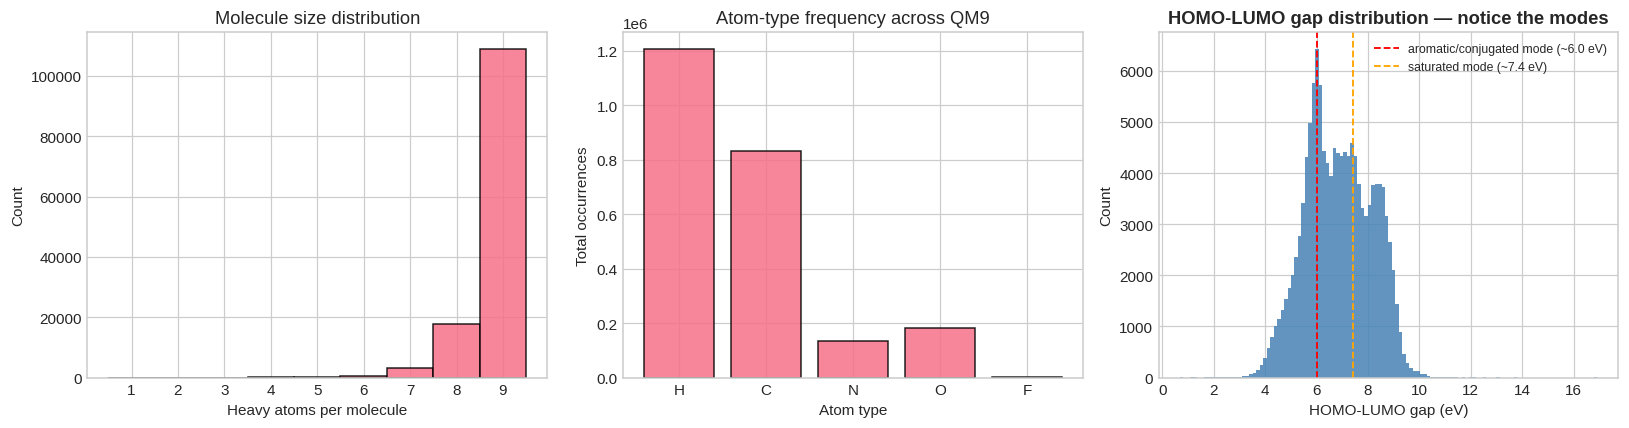

In [7]:
# ---- Overview figure: size + atom types + gap distribution ----
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Heavy-atom count histogram
axes[0].hist(num_heavy, bins=range(1, 11), edgecolor='black', align='left', alpha=0.85)
axes[0].set_xlabel('Heavy atoms per molecule')
axes[0].set_ylabel('Count')
axes[0].set_title('Molecule size distribution')
axes[0].set_xticks(range(1, 10))

# Atom-type bar chart
atom_labels = [ATOM_SYMBOLS[z] for z in vals]
axes[1].bar(atom_labels, cnts, edgecolor='black', alpha=0.85)
axes[1].set_xlabel('Atom type')
axes[1].set_ylabel('Total occurrences')
axes[1].set_title('Atom-type frequency across QM9')

# HOMO-LUMO gap — the KEY plot
axes[2].hist(gaps, bins=120, edgecolor='none', alpha=0.85, color='steelblue')
axes[2].set_xlabel('HOMO-LUMO gap (eV)')
axes[2].set_ylabel('Count')
axes[2].set_title('HOMO-LUMO gap distribution — notice the modes', fontweight='bold')
# Annotate the two dominant modes identified from the histogram peak analysis
axes[2].axvline(x=6.0, color='red', linestyle='--', linewidth=1.2, label='aromatic/conjugated mode (~6.0 eV)')
axes[2].axvline(x=7.4, color='orange', linestyle='--', linewidth=1.2, label='saturated mode (~7.4 eV)')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'eda_overview.png'), bbox_inches='tight')
plt.show()

Again, the gap distribution is the most important result, since it is not unimodal. There are at least two visible modes: a taller one near **6.0 eV** and a broader one near **7.4 eV** (and perhaps even a third one at ~8.3). This multi-modality reflects the distinct **chemical families** within the QM9 dataset. Aromatic and conjugated molecules cluster around 6 eV because pi-electron delocalization shrinks the gap. Saturated molecules (no double bonds, no rings) push toward 7–9 eV. Purely aliphatic chains and tiny molecules like methane reach 10–14 eV. Molecules with heteroatoms (N, O) fall in between.

This tells us something important before we run a single model: the gap is not just a function of how many atoms a molecule has. Its distribution is shaped by *structural* features. This includes the connectivity pattern, the ring structure, the bond types. A model that only counts atoms cannot reproduce that structure.

2D renders of 8 randomly sampled molecules (legend shows HOMO-LUMO gap):


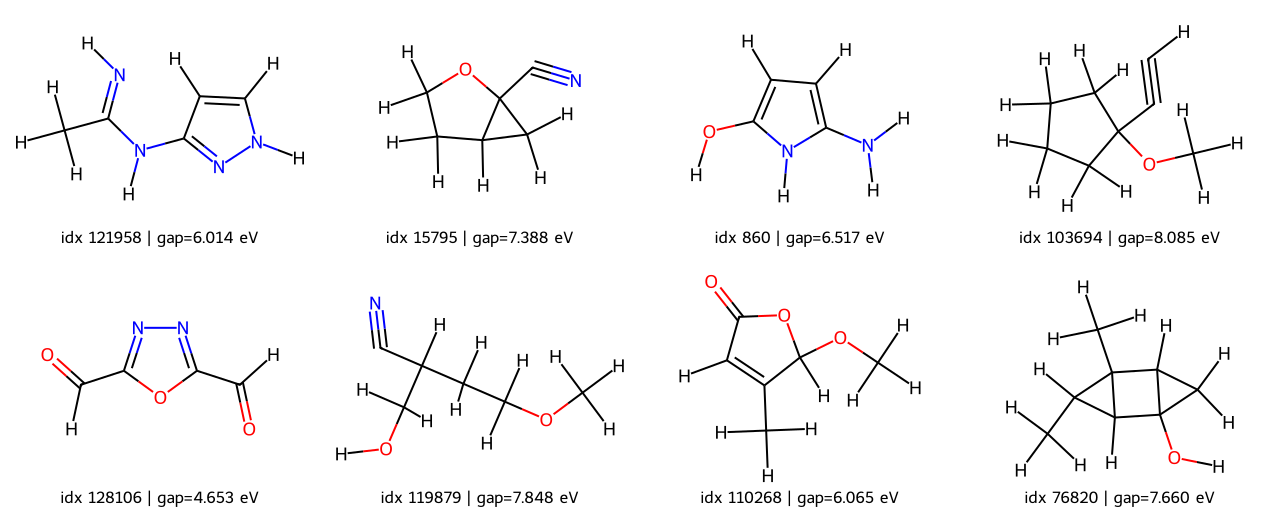

In [8]:
# ---- Molecule helper: PyG -> RDKit (reused throughout notebook) ----
def pyg_to_rdkit(data):
    """Convert a PyG data object to an RDKit molecule with 3D conformer."""
    mol = Chem.RWMol()
    for z in data.z:
        mol.AddAtom(Chem.Atom(ATOM_SYMBOLS[int(z)]))
    if data.edge_attr is not None:
        bond_map = {0: Chem.BondType.SINGLE, 1: Chem.BondType.DOUBLE,
                    2: Chem.BondType.TRIPLE, 3: Chem.BondType.AROMATIC}
        seen = set()
        for (i, j), btype in zip(data.edge_index.t().tolist(),
                                  data.edge_attr[:, :4].argmax(dim=1).tolist()):
            bond = (min(i, j), max(i, j))
            if bond not in seen:
                mol.AddBond(i, j, bond_map[btype])
                seen.add(bond)
    mol = mol.GetMol()
    conf = Chem.Conformer(data.pos.shape[0])
    for k in range(data.pos.shape[0]):
        conf.SetAtomPosition(k, data.pos[k].tolist())
    mol.AddConformer(conf)
    AllChem.Compute2DCoords(mol)
    sanitize_ok = True
    try:
        Chem.SanitizeMol(mol)
    except Exception:
        sanitize_ok = False
    return mol, sanitize_ok

# 2x4 grid of random molecules
np.random.seed(SEED)
sample_idx = np.random.randint(0, N, 8).tolist()
mols = [pyg_to_rdkit(dataset[i])[0] for i in sample_idx]
legends = [f"idx {i} | gap={dataset[i].y[0, GAP_IDX]:.3f} eV" for i in sample_idx]
grid = Draw.MolsToGridImage(mols, molsPerRow=4, subImgSize=(320, 260), legends=legends)
print("2D renders of 8 randomly sampled molecules (legend shows HOMO-LUMO gap):")
display(grid)

Even this small gallery makes the structural diversity visible: simple chains, fused rings, heteroatoms at different positions, varying degrees of unsaturation. The gap values printed in the legends already hint at the pattern: the aromatic/conjugated molecules (visually denser) tend to appear at lower gap values.

<a id='q0'></a>
## 4. Q0: The Composition Floor

**Research question:** How accurately can we predict the HOMO-LUMO gap using *only the atom counts*, i.e. no structural information at all?

This is the floor. If a model that does not know anything about connectivity can already predict the gap well, then topology tells us nothing extra. If this model performs poorly, we know that structure matters and the graph-mining and GNN approaches have room to add value.

We featurize each molecule as a 5-vector `[#H, #C, #N, #O, #F]` and fit a Ridge regression. We evaluate on a **Bemis-Murcko scaffold split** (80/10/10): molecules are grouped by their Murcko core and entire scaffold groups are assigned to a single fold. This prevents near-duplicate leakage between train and test that inflates results under random splits. We retain the random split for a side-by-side robustness check at the end of the classical baseline section; all headline numbers in this report use the scaffold split.

In [9]:
# ---- Build atom-count feature matrix and define the shared split ----
print("Building atom-count feature matrix...")
atom_types = [1, 6, 7, 8, 9]

X_atom = np.zeros((N, len(atom_types)), dtype=np.float32)
y_gap  = np.zeros(N, dtype=np.float32)

for i, data in enumerate(tqdm(dataset, desc='Counting atoms')):
    for j, z in enumerate(atom_types):
        X_atom[i, j] = (data.z == z).sum().item()
    y_gap[i] = data.y[0, GAP_IDX].item()

# Shared 80/10/10 split — used for ALL models in this notebook
rng = np.random.default_rng(SEED)
all_idx = rng.permutation(N)
n_train = int(0.80 * N)
n_val   = int(0.10 * N)
train_idx = all_idx[:n_train]
val_idx   = all_idx[n_train:n_train + n_val]
test_idx  = all_idx[n_train + n_val:]

print(f"Split sizes — train: {len(train_idx):,}  val: {len(val_idx):,}  test: {len(test_idx):,}")

Building atom-count feature matrix...


Counting atoms: 100%|██████████| 130831/130831 [00:02<00:00, 44126.23it/s]

Split sizes — train: 104,664  val: 13,083  test: 13,084


In [24]:
# ---- Bemis-Murcko scaffold split (primary evaluation split) ----
# Random splits inflate QM9 results because near-duplicate molecules
# (single substituent swaps) leak across train/test. Scaffold splits
# group molecules by their Murcko core and assign whole groups to one
# fold, so the test set contains chemical scaffolds the model never saw.
from rdkit.Chem.Scaffolds import MurckoScaffold

SCAFFOLD_CACHE = os.path.join(DATA_DIR, 'scaffold_split.npz')

def _scaffold_smiles(smi):
    m = Chem.MolFromSmiles(smi)
    if m is None:
        return ''
    try:
        return MurckoScaffold.MurckoScaffoldSmiles(mol=m, includeChirality=False)
    except Exception:
        return ''

def make_scaffold_split(dataset, train_frac=0.80, val_frac=0.10):
    buckets = {}
    for i, d in enumerate(tqdm(dataset, desc='Computing Murcko scaffolds')):
        s = _scaffold_smiles(d.smiles)
        buckets.setdefault(s, []).append(i)
    groups = sorted(buckets.values(), key=lambda g: (len(g), g[0]), reverse=True)
    n = len(dataset)
    n_tr = int(train_frac * n)
    n_val = int(val_frac * n)
    tr, va, te = [], [], []
    for g in groups:
        if len(tr) + len(g) <= n_tr:
            tr.extend(g)
        elif len(va) + len(g) <= n_val:
            va.extend(g)
        else:
            te.extend(g)
    return (np.array(tr, dtype=np.int64),
            np.array(va, dtype=np.int64),
            np.array(te, dtype=np.int64),
            len(buckets))

if os.path.exists(SCAFFOLD_CACHE):
    z = np.load(SCAFFOLD_CACHE)
    train_idx_scaf, val_idx_scaf, test_idx_scaf = z['train'], z['val'], z['test']
    n_scaffolds = int(z['n_scaffolds'])
    print(f"Loaded cached scaffold split")
else:
    train_idx_scaf, val_idx_scaf, test_idx_scaf, n_scaffolds = make_scaffold_split(dataset)
    np.savez(SCAFFOLD_CACHE,
             train=train_idx_scaf, val=val_idx_scaf, test=test_idx_scaf,
             n_scaffolds=n_scaffolds)
    print(f"Saved scaffold split to {SCAFFOLD_CACHE}")

print(f"Distinct Murcko scaffolds: {n_scaffolds:,}")
print(f"Scaffold split - train: {len(train_idx_scaf):,}  val: {len(val_idx_scaf):,}  test: {len(test_idx_scaf):,}")

# Keep the random split available for the side-by-side comparison.
train_idx_rand = train_idx
val_idx_rand   = val_idx
test_idx_rand  = test_idx

# Promote scaffold split to be the default for downstream sections.
train_idx = train_idx_scaf
val_idx   = val_idx_scaf
test_idx  = test_idx_scaf


Loaded cached scaffold split
Distinct Murcko scaffolds: 14,468
Scaffold split - train: 104,664  val: 13,083  test: 13,084


Q0 — Atom-count Ridge
  Test MAE  : 0.8836 eV
  Test RMSE : 1.0681 eV
  Test R²   : 0.3597


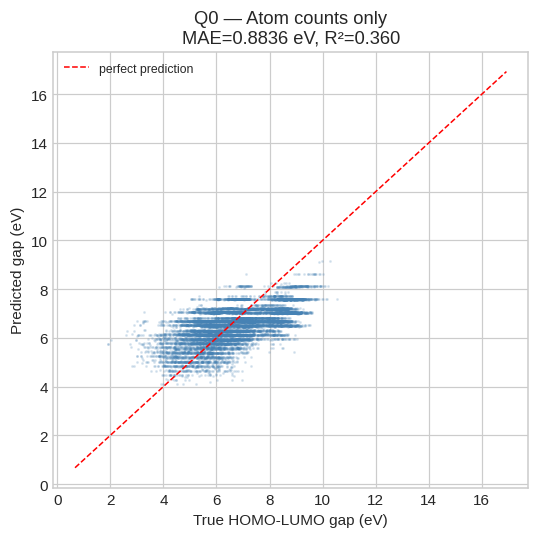

In [25]:
# ---- Q0: fit Ridge on atom counts ----
scaler_q0 = StandardScaler()
X_tr = scaler_q0.fit_transform(X_atom[train_idx])
X_te = scaler_q0.transform(X_atom[test_idx])

ridge_q0 = Ridge(alpha=1.0)
ridge_q0.fit(X_tr, y_gap[train_idx])
y_pred_q0 = ridge_q0.predict(X_te)

mae_q0  = mean_absolute_error(y_gap[test_idx], y_pred_q0)
rmse_q0 = np.sqrt(mean_squared_error(y_gap[test_idx], y_pred_q0))
r2_q0   = r2_score(y_gap[test_idx], y_pred_q0)

print(f"Q0 — Atom-count Ridge")
print(f"  Test MAE  : {mae_q0:.4f} eV")
print(f"  Test RMSE : {rmse_q0:.4f} eV")
print(f"  Test R²   : {r2_q0:.4f}")

# Scatter: predicted vs. actual
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(y_gap[test_idx], y_pred_q0, s=1, alpha=0.15, color='steelblue')
lims = [y_gap.min(), y_gap.max()]
ax.plot(lims, lims, 'r--', linewidth=1, label='perfect prediction')
ax.set_xlabel('True HOMO-LUMO gap (eV)')
ax.set_ylabel('Predicted gap (eV)')
ax.set_title(f'Q0 — Atom counts only\nMAE={mae_q0:.4f} eV, R²={r2_q0:.3f}')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'q0_scatter.png'), bbox_inches='tight')
plt.show()

**The Composition Floor.** Atom counts alone give us a test MAE around **0.88 eV** and an R² around 0.36. The scatter plot is diagnostic: predictions cluster in narrow horizontal bands, unable to reproduce the full range of gap values. The model has learned *average chemistry* (more carbon atoms generally means a certain gap) but is completely blind to how those atoms are connected. All the spread in the true gap that comes from ring structure, conjugation, and bond types is invisible to this model.

These results is what makes it the floor for this project. It proves this problem is not trivially/naively solved, and any model that knows about connectivity should beat this number, how much it beats it by is the interesting question.

<a id='q1'></a>
## 5. Q1: The Graph-Mining Tour

**Research question:** How much can classical graph-mining features (ring structure, community detection, centrality) improve on atom counts alone? And do these features tell a chemically interpretable story?

We now extract hand-crafted graph features from every molecule. Because this computation takes ~5-15 minutes on the full 130k dataset, we cache the result to `qm9_data/graph_features.parquet` and reload it on subsequent runs.

We analyze features in three groups (Q1a–Q1c) before combining them all into a single Ridge model (Q1d).

In [27]:
# ---- FEATURE EXTRACTION CODE BLOCK ----
FEAT_CACHE = os.path.join(DATA_DIR, 'graph_features.parquet')
FEAT_CACHE_CSV = os.path.join(DATA_DIR, 'graph_features.csv')

def _coerce_graph_feat_dtypes(df):
    """Use plain NumPy dtypes so Parquet round-trip avoids Arrow extension metadata issues."""
    out = df.copy()
    out.index = out.index.astype(np.int64)
    for c in out.columns:
        out[c] = np.asarray(out[c], dtype=np.float64)
    return out

df_feat = None
if os.path.exists(FEAT_CACHE):
    try:
        df_feat = _coerce_graph_feat_dtypes(pd.read_parquet(FEAT_CACHE, engine='pyarrow'))
        print(f"Loading cached graph features")
    except Exception as e:
        print(f"Could not read {FEAT_CACHE} ({e}). Trying CSV or rebuild.")
if df_feat is None and os.path.exists(FEAT_CACHE_CSV):
    df_feat = _coerce_graph_feat_dtypes(pd.read_csv(FEAT_CACHE_CSV, index_col=0))
    print(f"Loading cached graph features")
if df_feat is None:
    print("Computing graph features for all molecules (this takes ~5-15 min)...")
    records = []
    n_sanitize_fail = 0
    for i, data in enumerate(tqdm(dataset, desc='Extracting features')):
        mol, sanitize_ok = pyg_to_rdkit(data)
        if not sanitize_ok:
            n_sanitize_fail += 1
        G   = to_networkx(data, to_undirected=True)

        # --- Rings and motifs ---
        n_rings    = len(GetSSSR(mol))
        ring_info  = mol.GetRingInfo()
        n_arom     = sum(1 for r in ring_info.AtomRings()
                         if all(mol.GetAtomWithIdx(a).GetIsAromatic() for a in r))
        n_conj_bonds = sum(1 for b in mol.GetBonds() if b.GetIsConjugated())
        n_double   = sum(1 for b in mol.GetBonds() if b.GetBondTypeAsDouble() == 2.0)
        n_triple   = sum(1 for b in mol.GetBonds() if b.GetBondTypeAsDouble() == 3.0)

        # --- Louvain community detection ---
        if len(G.nodes) > 1:
            partition = cm.best_partition(G, random_state=SEED)
            comm_sizes = list(pd.Series(partition.values()).value_counts())
            n_comm     = len(comm_sizes)
            modularity_val = cm.modularity(partition, G)
            avg_comm_size  = np.mean(comm_sizes)
            std_comm_size  = np.std(comm_sizes)
        else:
            partition = {0: 0}
            n_comm = 1; modularity_val = 0.0; avg_comm_size = 1.0; std_comm_size = 0.0

        # --- Centrality measures ---
        deg_cent  = nx.degree_centrality(G)
        try:
            bet_cent = nx.betweenness_centrality(G, normalized=True)
        except Exception:
            bet_cent = {n: 0.0 for n in G.nodes}
        pr = nx.pagerank(G, alpha=0.85)

        deg_vals = list(deg_cent.values())
        bet_vals = list(bet_cent.values())
        pr_vals  = list(pr.values())

        records.append({
            'idx':         i,
            'gap':         data.y[0, GAP_IDX].item(),
            # rings
            'n_rings':     n_rings,
            'n_arom':      n_arom,
            'n_conj':      n_conj_bonds,
            'n_double':    n_double,
            'n_triple':    n_triple,
            # communities
            'n_comm':      n_comm,
            'modularity':  modularity_val,
            'avg_comm':    avg_comm_size,
            'std_comm':    std_comm_size,
            # centrality (mean/max/std per molecule)
            'deg_mean':    np.mean(deg_vals),
            'deg_max':     np.max(deg_vals),
            'deg_std':     np.std(deg_vals),
            'bet_mean':    np.mean(bet_vals),
            'bet_max':     np.max(bet_vals),
            'bet_std':     np.std(bet_vals),
            'pr_mean':     np.mean(pr_vals),
            'pr_max':      np.max(pr_vals),
            'pr_std':      np.std(pr_vals),
        })

    print(f"Sanitization failures: {n_sanitize_fail:,}/{N:,} "
          f"({n_sanitize_fail/N*100:.2f}%) — features for these molecules "
          f"may be partially zeroed (RDKit ring/aromaticity calls fail silently).")
    df_feat = _coerce_graph_feat_dtypes(pd.DataFrame(records).set_index('idx'))
    try:
        df_feat.to_parquet(FEAT_CACHE, engine='pyarrow', index=True)
        print(f"Saved to {FEAT_CACHE}")
    except Exception as e:
        print(f"Parquet save failed ({e}); writing CSV fallback.")
        df_feat.to_csv(FEAT_CACHE_CSV)
        print(f"Saved to {FEAT_CACHE_CSV}")

print(f"Features shape: {df_feat.shape}")
df_feat.describe().round(4)

Loading cached graph features
Features shape: (130831, 19)


,gap,n_rings,n_arom,n_conj,n_double,n_triple,n_comm,modularity,avg_comm,std_comm,deg_mean,deg_max,deg_std,bet_mean,bet_max,bet_std,pr_mean,pr_max,pr_std
count,130831.0000,130831.0000,130831.0000,130831.0000,130831.0000,130831.0000,130831.0000,130831.0000,130831.0000,130831.0000,130831.0000,130831.0000,130831.0000,130831.0000,130831.0000,130831.0000,130831.0000,130831.0000,130831.0000
mean,6.8585,1.6309,0.1557,1.6702,0.6231,0.2800,4.2418,0.5003,4.3114,0.9422,0.1255,0.2395,0.0755,0.1430,0.5472,0.1827,0.0571,0.1093,0.0301
std,1.2842,0.9916,0.3777,2.6256,0.7492,0.5269,0.6970,0.0555,0.7341,0.4096,0.0249,0.0417,0.0103,0.0219,0.0986,0.0272,0.0105,0.0172,0.0035
min,0.6694,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,2.0000,0.0000,0.0690,0.1429,0.0000,0.0966,0.1667,0.0000,0.0345,0.0692,0.0000
25%,5.9049,1.0000,0.0000,0.0000,0.0000,0.0000,4.0000,0.4644,3.8000,0.7071,0.1095,0.2105,0.0686,0.1270,0.4789,0.1625,0.0500,0.0975,0.0279
50%,6.8083,2.0000,0.0000,0.0000,0.0000,0.0000,4.0000,0.5038,4.2500,0.8292,0.1242,0.2353,0.0741,0.1382,0.5526,0.1808,0.0556,0.1069,0.0296
75%,7.8750,2.0000,0.0000,3.0000,1.0000,0.0000,5.0000,0.5391,4.7500,1.2247,0.1397,0.2667,0.0812,0.1554,0.6158,0.2024,0.0625,0.1180,0.0317
max,16.9282,6.0000,2.0000,10.0000,5.0000,4.0000,7.0000,0.6499,9.0000,2.8674,0.6667,1.0000,0.3000,0.3333,1.0000,0.4714,0.3333,0.4865,0.1378


<a id='q1a'></a>
### Q1a: Rings and Motifs

Rings are the most chemically meaningful structural feature in small organic molecules. Benzene (one aromatic ring) has a dramatically different gap from cyclohexane (one saturated ring) or hexane (no ring at all). We extract the SSSR (smallest set of smallest rings) count, aromatic ring count, conjugated bond count, and double/triple bond counts.

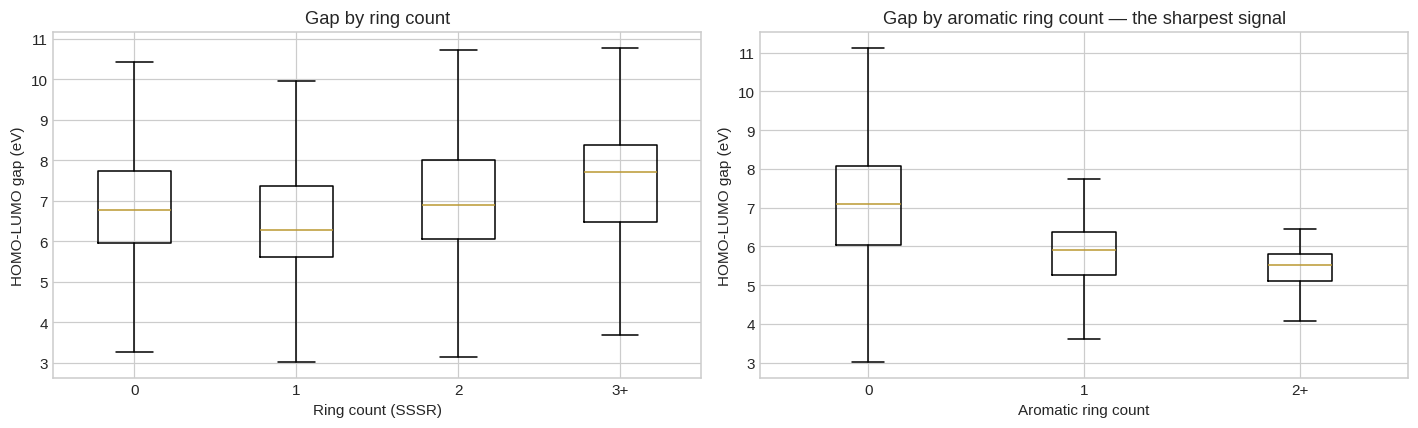

Spearman correlation with HOMO-LUMO gap (ring/motif features):
n_rings     0.2348
n_arom     -0.3576
n_conj     -0.5099
n_double   -0.6418
n_triple    0.0052


In [13]:
# ---- Q1a: Rings vs gap ----
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Box plot: total rings vs gap
ring_groups = df_feat['n_rings'].clip(0, 3).map({0:'0', 1:'1', 2:'2', 3:'3+'})
gap_by_ring = [df_feat.loc[ring_groups == k, 'gap'].values for k in ['0','1','2','3+']]
axes[0].boxplot(gap_by_ring, labels=['0','1','2','3+'], showfliers=False)
axes[0].set_xlabel('Ring count (SSSR)')
axes[0].set_ylabel('HOMO-LUMO gap (eV)')
axes[0].set_title('Gap by ring count')

# Aromatic rings — sharper signal
arom_groups = df_feat['n_arom'].clip(0, 2).map({0:'0', 1:'1', 2:'2+'})
gap_by_arom = [df_feat.loc[arom_groups == k, 'gap'].values for k in ['0','1','2+']]
axes[1].boxplot(gap_by_arom, labels=['0','1','2+'], showfliers=False)
axes[1].set_xlabel('Aromatic ring count')
axes[1].set_ylabel('HOMO-LUMO gap (eV)')
axes[1].set_title('Gap by aromatic ring count — the sharpest signal')

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'q1a_rings.png'), bbox_inches='tight')
plt.show()

# Correlation
ring_feats = ['n_rings','n_arom','n_conj','n_double','n_triple']
corr = df_feat[ring_feats + ['gap']].corr(method='spearman')['gap'].drop('gap')
print("Spearman correlation with HOMO-LUMO gap (ring/motif features):")
print(corr.round(4).to_string())

**The Ring Penalty.** By Spearman correlation, **double bond count is the single strongest hand-crafted feature** (ρ = −0.64), followed closely by conjugated bond count (ρ = −0.51). Aromatic ring count contributes a meaningful negative signal too (ρ = −0.36), and the boxplot makes this visually tangible: molecules with one aromatic ring have a median gap **~1.2 eV lower** than those with zero aromatic rings (median drops from ~7.1 eV to ~5.9 eV), and molecules with two or more aromatic rings drop further to ~5.5 eV. The interpretation is chemically sound: aromatic and conjugated systems delocalize pi electrons across the whole molecule, shrinking the gap between occupied and unoccupied orbitals. 

Saturated rings (total rings but no aromatic rings) show a weaker and non-monotonic effect, i.e. they perturb geometry but do not dramatically change the electronic structure. This nuance is already revealing a limitation of simple ring counting: *what kind* of ring matters, not just *how many*.

<a id='q1b'></a>
### Q1b: Louvain Community Detection

Louvain community detection partitions the atoms of a molecule into groups that are more densely connected to each other than to the rest of the graph. In a molecular context, this should approximate *functional fragments*, which are groups of atoms that act together chemically (a ring, a carbonyl group, an amine branch).

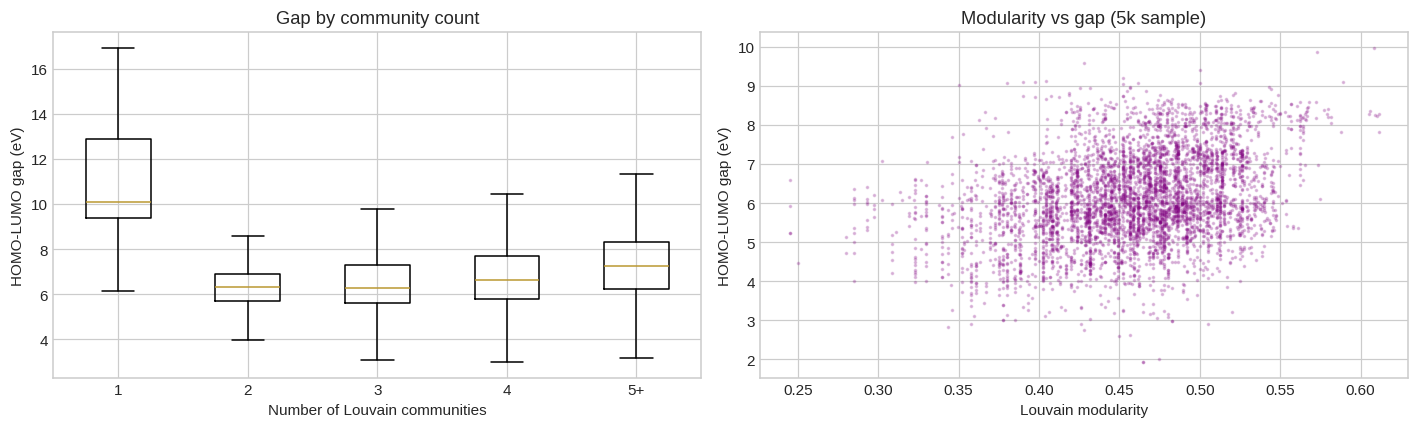

Spearman correlation with gap (community features):
n_comm        0.2367
modularity    0.3369
avg_comm      0.3022
std_comm      0.2131


In [14]:
# ---- Q1b: Communities vs gap ----
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Number of communities vs gap
comm_groups = df_feat['n_comm'].apply(lambda x: '5+' if int(x) >= 5 else str(int(x)))
comm_labels = ['1','2','3','4','5+']
gap_by_comm = [df_feat.loc[comm_groups == k, 'gap'].values for k in comm_labels]
axes[0].boxplot(gap_by_comm, labels=comm_labels, showfliers=False)
axes[0].set_xlabel('Number of Louvain communities')
axes[0].set_ylabel('HOMO-LUMO gap (eV)')
axes[0].set_title('Gap by community count')

# Modularity vs gap (scatter on 5k sample for speed)
sample_mask = np.zeros(N, dtype=bool)
sample_mask[test_idx[:5000]] = True
axes[1].scatter(df_feat.loc[sample_mask, 'modularity'],
                df_feat.loc[sample_mask, 'gap'],
                s=2, alpha=0.2, color='purple')
axes[1].set_xlabel('Louvain modularity')
axes[1].set_ylabel('HOMO-LUMO gap (eV)')
axes[1].set_title('Modularity vs gap (5k sample)')

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'q1b_communities.png'), bbox_inches='tight')
plt.show()

comm_feats = ['n_comm','modularity','avg_comm','std_comm']
corr_c = df_feat[comm_feats + ['gap']].corr(method='spearman')['gap'].drop('gap')
print("Spearman correlation with gap (community features):")
print(corr_c.round(4).to_string())

**Communities as Proto-Fragments.** Molecules with more communities tend to have higher gaps: a many-fragmented structure indicates a molecule without extended conjugation, which chemically raises the gap. Modularity tells a more nuanced story: very high modularity means the molecule decomposes cleanly into isolated clusters, consistent with a saturated, high-gap structure. Low modularity means the bonds are more evenly distributed, which can reflect both ring delocalization (low gap) and highly branched saturated chains (moderate gap), so the signal is weaker.

The key limitation here is that Louvain treats all bonds as equal-weight edges. It cannot distinguish a single C-C bond from an aromatic C=C bond. This will become a central theme of the Interlude section.

<a id='q1c'></a>
### Q1c: Centrality and PageRank

Centrality measures assign importance to individual atoms within the molecular graph. We summarize each molecule by the mean, max, and standard deviation of three centrality scores: degree centrality, betweenness centrality, and PageRank. The variance of PageRank is particularly interesting: a high-variance distribution means one atom dominates the molecule's graph, while a low-variance distribution means all atoms are equally connected, which is the signature of a ring.

Spearman correlation with gap (centrality features):
deg_mean   -0.4769
deg_max    -0.4944
deg_std    -0.1984
bet_mean   -0.4828
bet_max     0.0855
bet_std    -0.0541
pr_mean    -0.5286
pr_max     -0.5355
pr_std     -0.3248


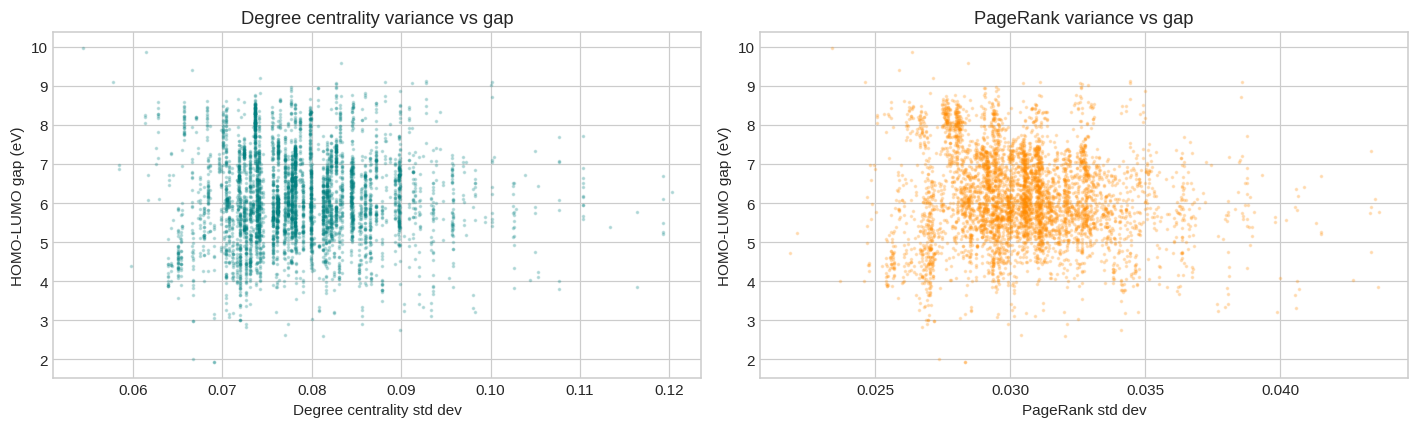

In [15]:
# ---- Q1c: Centrality vs gap ----
cent_feats = ['deg_mean','deg_max','deg_std','bet_mean','bet_max','bet_std',
              'pr_mean','pr_max','pr_std']
corr_cent = df_feat[cent_feats + ['gap']].corr(method='spearman')['gap'].drop('gap')
print("Spearman correlation with gap (centrality features):")
print(corr_cent.round(4).to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Degree std vs gap — 5k sample
axes[0].scatter(df_feat.loc[sample_mask, 'deg_std'],
                df_feat.loc[sample_mask, 'gap'],
                s=2, alpha=0.2, color='teal')
axes[0].set_xlabel('Degree centrality std dev')
axes[0].set_ylabel('HOMO-LUMO gap (eV)')
axes[0].set_title('Degree centrality variance vs gap')

# PageRank std vs gap
axes[1].scatter(df_feat.loc[sample_mask, 'pr_std'],
                df_feat.loc[sample_mask, 'gap'],
                s=2, alpha=0.2, color='darkorange')
axes[1].set_xlabel('PageRank std dev')
axes[1].set_ylabel('HOMO-LUMO gap (eV)')
axes[1].set_title('PageRank variance vs gap')

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'q1c_centrality.png'), bbox_inches='tight')
plt.show()

**Who wins amongst these three?** While the graphs don't tell us much other than PageRank having a lesser spread than degree centrality, the PageRank maximum and mean are the strongest centrality signals (Spearman ≈ −0.53). Both are **negatively** correlated with the gap: molecules where atoms carry higher PageRank scores (i.e., molecules with denser, more interconnected graphs) tend to have *lower* gaps. This makes chemical sense: highly connected atoms appear in ring junctions, conjugated frameworks, and heteroatom-rich scaffolds, all of which reduce the gap through pi-electron delocalization (In simpler terms, when electrons can spread out more easily across a molecule instead of being stuck between just a few atoms, it takes less energy to move them around, so the energy gap gets smaller). PageRank std is also negative (−0.32), meaning concentrated PageRank (one hub atom dominating) associates with lower gaps, not higher, which is contrary to a naive "chain molecule has a hub" intuition.

Degree centrality shows a similar negative trend (deg_max ≈ −0.49) but with slightly weaker signal than PageRank, since QM9 molecules are small and raw degree differences are limited.

Compared to Q1a: all centrality features are weaker than double bond count (ρ = −0.64). However, PageRank max and mean (≈ −0.53) are competitive with (and slightly stronger than) conjugated bond count (ρ = −0.51). This is a notable finding: topology-based centrality can partially proxy for bonding patterns, but it does so indirectly and without the chemical interpretability of explicitly counting conjugated bonds. The GCN in Q2 will have direct access to bond type labels, making it the first model that can cleanly separate bond order effects from graph shape effects.

<a id='q1d'></a>
### Q1d: Combined Ridge Model and Results Table

We now combine all hand-crafted features — atom counts (Q0), ring/motif features (Q1a), community features (Q1b), and centrality features (Q1c) — into a single Ridge regression and evaluate on the same held-out test set as Q0.

Q1 — Graph-mining Ridge (full features)
  Test MAE  : 0.5636 eV
  Test RMSE : 0.7426 eV
  Test R²   : 0.6905

  Improvement over Q0:
    MAE   delta: +0.3200 eV  (+36.2%)
    R²    delta: +0.3309


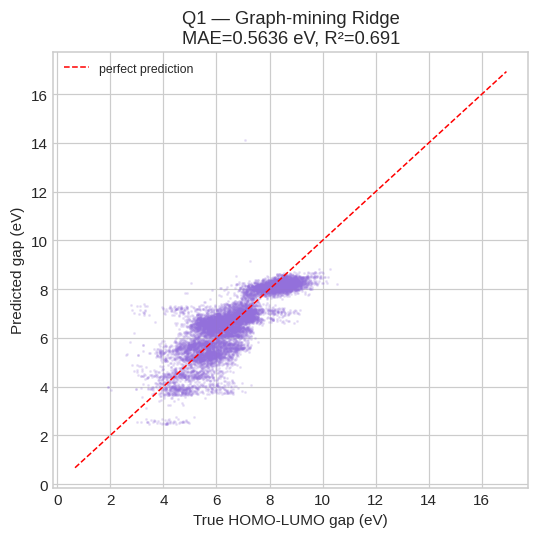

In [16]:
# ---- Q1d: Full feature matrix ----
graph_feat_cols = ['n_rings','n_arom','n_conj','n_double','n_triple',
                   'n_comm','modularity','avg_comm','std_comm',
                   'deg_mean','deg_max','deg_std',
                   'bet_mean','bet_max','bet_std',
                   'pr_mean','pr_max','pr_std']

# Align order with dataset indices
X_graph = df_feat.loc[range(N), graph_feat_cols].values.astype(np.float32)

# Concatenate with atom counts
X_full = np.hstack([X_atom, X_graph])

scaler_q1 = StandardScaler()
X_tr1 = scaler_q1.fit_transform(X_full[train_idx])
X_te1 = scaler_q1.transform(X_full[test_idx])

ridge_q1 = Ridge(alpha=1.0)
ridge_q1.fit(X_tr1, y_gap[train_idx])
y_pred_q1 = ridge_q1.predict(X_te1)

mae_q1  = mean_absolute_error(y_gap[test_idx], y_pred_q1)
rmse_q1 = np.sqrt(mean_squared_error(y_gap[test_idx], y_pred_q1))
r2_q1   = r2_score(y_gap[test_idx], y_pred_q1)

print(f"Q1 — Graph-mining Ridge (full features)")
print(f"  Test MAE  : {mae_q1:.4f} eV")
print(f"  Test RMSE : {rmse_q1:.4f} eV")
print(f"  Test R²   : {r2_q1:.4f}")

# Improvement over Q0
print(f"\n  Improvement over Q0:")
print(f"    MAE   delta: {mae_q0 - mae_q1:+.4f} eV  ({(mae_q0 - mae_q1)/mae_q0*100:+.1f}%)")
print(f"    R²    delta: {r2_q1 - r2_q0:+.4f}")

# Scatter: predicted vs. actual (Q1)
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(y_gap[test_idx], y_pred_q1, s=1, alpha=0.15, color='mediumpurple')
lims = [y_gap.min(), y_gap.max()]
ax.plot(lims, lims, 'r--', linewidth=1, label='perfect prediction')
ax.set_xlabel('True HOMO-LUMO gap (eV)')
ax.set_ylabel('Predicted gap (eV)')
ax.set_title(f'Q1 — Graph-mining Ridge\nMAE={mae_q1:.4f} eV, R²={r2_q1:.3f}')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'q1_scatter.png'), bbox_inches='tight')
plt.show()

In [17]:
# ---- Q1 Ablation: which feature group drives the lift over Q0? ----
ring_cols = ['n_rings','n_arom','n_conj','n_double','n_triple']
comm_cols = ['n_comm','modularity','avg_comm','std_comm']
cent_cols = ['deg_mean','deg_max','deg_std',
             'bet_mean','bet_max','bet_std',
             'pr_mean','pr_max','pr_std']

def _fit_ridge_block(X, train_idx, test_idx, y):
    sc   = StandardScaler()
    X_tr = sc.fit_transform(X[train_idx])
    X_te = sc.transform(X[test_idx])
    mdl  = Ridge(alpha=1.0).fit(X_tr, y[train_idx])
    p    = mdl.predict(X_te)
    return (mean_absolute_error(y[test_idx], p),
            r2_score(y[test_idx], p))

X_rings = np.hstack([X_atom, df_feat.loc[range(N), ring_cols].values.astype(np.float32)])
X_comms = np.hstack([X_atom, df_feat.loc[range(N), comm_cols].values.astype(np.float32)])
X_cents = np.hstack([X_atom, df_feat.loc[range(N), cent_cols].values.astype(np.float32)])

ablation_specs = [
    ('Q0   — atoms only',              X_atom),
    ('Q1a  — atoms + rings/motifs',    X_rings),
    ('Q1b  — atoms + communities',     X_comms),
    ('Q1c  — atoms + centrality',      X_cents),
    ('Q1   — atoms + ALL graph feats', X_full),
]

ablation_rows = []
for name, X in ablation_specs:
    mae, r2 = _fit_ridge_block(X.astype(np.float32), train_idx, test_idx, y_gap)
    ablation_rows.append({'Model': name,
                          'Test MAE (eV)': f'{mae:.4f}',
                          'Test R²':       f'{r2:.4f}',
                          'MAE delta vs Q0 (eV)': f'{mae_q0 - mae:+.4f}'})

ablation_df = pd.DataFrame(ablation_rows)
print("=== Q1 Ablation — same train/test split, single feature group at a time ===")
print(ablation_df.to_string(index=False))

mae_q1a = float(ablation_df.loc[1, 'Test MAE (eV)'])
mae_q1b = float(ablation_df.loc[2, 'Test MAE (eV)'])
mae_q1c = float(ablation_df.loc[3, 'Test MAE (eV)'])

=== Q1 Ablation — same train/test split, single feature group at a time ===
                         Model Test MAE (eV) Test R² MAE delta vs Q0 (eV)
             Q0   — atoms only        0.8836  0.3597              +0.0000
   Q1a  — atoms + rings/motifs        0.6086  0.6512              +0.2751
    Q1b  — atoms + communities        0.8274  0.4234              +0.0562
     Q1c  — atoms + centrality        0.8733  0.3438              +0.0103
Q1   — atoms + ALL graph feats        0.5636  0.6905              +0.3200


In [18]:
# ---- Robustness check: random split vs scaffold split (Q0 and Q1) ----

def _fit_ridge_block(X, train_idx, test_idx, y_gap):
    sc   = StandardScaler()
    X_tr = sc.fit_transform(X[train_idx])
    X_te = sc.transform(X[test_idx])
    mdl  = Ridge(alpha=1.0).fit(X_tr, y_gap[train_idx])
    p    = mdl.predict(X_te)
    return (mean_absolute_error(y_gap[test_idx], p),
            r2_score(y_gap[test_idx], p))

robust_rows = []
for split_name, tr, te in [('random',   train_idx_rand, test_idx_rand),
                           ('scaffold', train_idx_scaf, test_idx_scaf)]:
    mae0, r20 = _fit_ridge_block(X_atom.astype(np.float32),  tr, te, y_gap)
    mae1, r21 = _fit_ridge_block(X_full.astype(np.float32),  tr, te, y_gap)
    robust_rows.append({'Split': split_name,
                        'Q0 MAE': f'{mae0:.4f}', 'Q0 R²': f'{r20:.4f}',
                        'Q1 MAE': f'{mae1:.4f}', 'Q1 R²': f'{r21:.4f}'})
print("=== Random vs Scaffold split - Q0 and Q1 ===")
print(pd.DataFrame(robust_rows).to_string(index=False))


=== Random vs Scaffold split - Q0 and Q1 ===
   Split Q0 MAE  Q0 R² Q1 MAE  Q1 R²
  random 0.8171 0.4033 0.5092 0.7385
scaffold 0.8836 0.3597 0.5636 0.6905


In [19]:
# ---- Running results table (Q0 and Q1; Q2 to be added in §7) ----
results = pd.DataFrame([
    {'Model': 'Q0 — Ridge (atom counts only)',
     'Features': '5 atom-count scalars',
     'Test MAE (eV)': f'{mae_q0:.4f}',
     'Test R²': f'{r2_q0:.4f}'},
    {'Model': 'Q1 — Ridge (graph-mining features)',
     'Features': 'atom counts + 18 graph features',
     'Test MAE (eV)': f'{mae_q1:.4f}',
     'Test R²': f'{r2_q1:.4f}'},
])
print("=== Running Results Table ===")
print(results.to_string(index=False))

=== Running Results Table ===
                             Model                        Features Test MAE (eV) Test R²
     Q0 — Ridge (atom counts only)            5 atom-count scalars        0.8836  0.3597
Q1 — Ridge (graph-mining features) atom counts + 18 graph features        0.5636  0.6905


The graph-mining features improve on atom counts by **~36% in MAE** (0.88 -> 0.56 eV) and lift R² from 0.36 to 0.69. This shows that ring counts, conjugation counts, and Louvain community statistics all carry genuine chemical information for better molecule property interpretation. Yet the model still cannot reproduce the full spread of the gap distribution, and the scatter plot looks qualitatively similar to Q0: the model anchors on mean behavior within chemical families but misses the fine-grained variation.

Why is this? Because all 18 graph features are *global summaries*. They collapse the entire molecular graph into a handful of scalars, discarding the spatial pattern of how atoms are connected. A linear model operating on these summaries cannot learn the difference between a double bond in a carbonyl group and a double bond in a conjugated chain, both look the same in terms of `n_double = 1`. To capture that distinction, we need a model that *reads the graph*, not just summarizes it.

<a id='interlude'></a>
## 6. Interlude: Does Graph Mining Rediscover Chemistry?

Before we move to the GCN, we pause to ask a more qualitative question: **when we run Louvain community detection on a molecular graph, does it find something chemically meaningful?**

We take a set of well-known small molecules (benzene, ethanol, acetone, furan, pyridine, ethylene, and others that appear in QM9) and compare Louvain's partition of the atoms to a ground-truth partition based on RDKit's functional group detection. If Louvain is recovering chemical fragments, its partitions should agree with known functional groups. If not, we learn something important about its limitations.

We match molecules by SMILES (Simplified Molecular Input Line Entry System) since QM9 does not provide SMILES directly. We search for known molecules by their expected atom counts and ring patterns.

In [20]:
# ---- Interlude: find well-known molecules in QM9 and label them by SMILES ----
# Map each candidate by (num_heavy_atoms, ring_count, atom formula) to QM9 index

# We'll use RDKit to canonicalize SMILES and match against QM9 molecules
from rdkit.Chem import MolToSmiles, MolFromSmiles

# Known molecules we want: name -> canonical SMILES
KNOWN_MOLECULES = {
    'Methane':       'C',
    'Ethylene':      'C=C',
    'Acetylene':     'C#C',
    'Formaldehyde':  'C=O',
    'Ethanol':       'CCO',
    'Acetone':       'CC(C)=O',
    'Furan':         'c1ccoc1',
    'Pyridine':      'c1ccncc1',
    'Methylamine':   'CN',
    'Acetic acid':   'CC(=O)O',
    'Dimethyl ether':'COC',
    'Acrylonitrile': 'C=CC#N',
    'Butadiene':     'C=CC=C',
    'Cyclopentane':  'C1CCCC1',
}

# Canonicalize
target_smiles = {}
for name, smi in KNOWN_MOLECULES.items():
    mol = MolFromSmiles(smi)
    if mol:
        target_smiles[name] = MolToSmiles(mol)

# Search QM9 for matches using data.smiles (with H's stripped before canonicalizing)
found = {}
print("Searching QM9 for known molecules...")
for i, data in enumerate(tqdm(dataset, desc='Matching')):
    try:
        raw_mol = MolFromSmiles(data.smiles)
        if raw_mol is None:
            continue
        mol_noH = Chem.RemoveHs(raw_mol)
        smi = MolToSmiles(mol_noH)
        for name, target in target_smiles.items():
            if name not in found and smi == target:
                found[name] = i
    except Exception:
        pass
    if len(found) == len(target_smiles):
        break

print(f"Found {len(found)} out of {len(target_smiles)} target molecules:")
for name, idx in found.items():
    gap_val = dataset[idx].y[0, GAP_IDX].item()
    print(f"  {name:20s} QM9 idx={idx:6d}  gap={gap_val:.4f} eV")

Searching QM9 for known molecules...


Matching: 100%|██████████| 130831/130831 [00:10<00:00, 12139.24it/s]

Found 9 out of 14 target molecules:
  Methane              QM9 idx=     0  gap=13.7363 eV
  Acetylene            QM9 idx=     3  gap=9.1185 eV
  Formaldehyde         QM9 idx=     5  gap=6.1579 eV
  Ethanol              QM9 idx=    13  gap=9.2981 eV
  Dimethyl ether       QM9 idx=    14  gap=9.3471 eV
  Acetone              QM9 idx=    17  gap=6.3783 eV
  Furan                QM9 idx=    51  gap=6.6532 eV
  Cyclopentane         QM9 idx=   155  gap=10.6723 eV
  Pyridine             QM9 idx=   209  gap=6.2396 eV


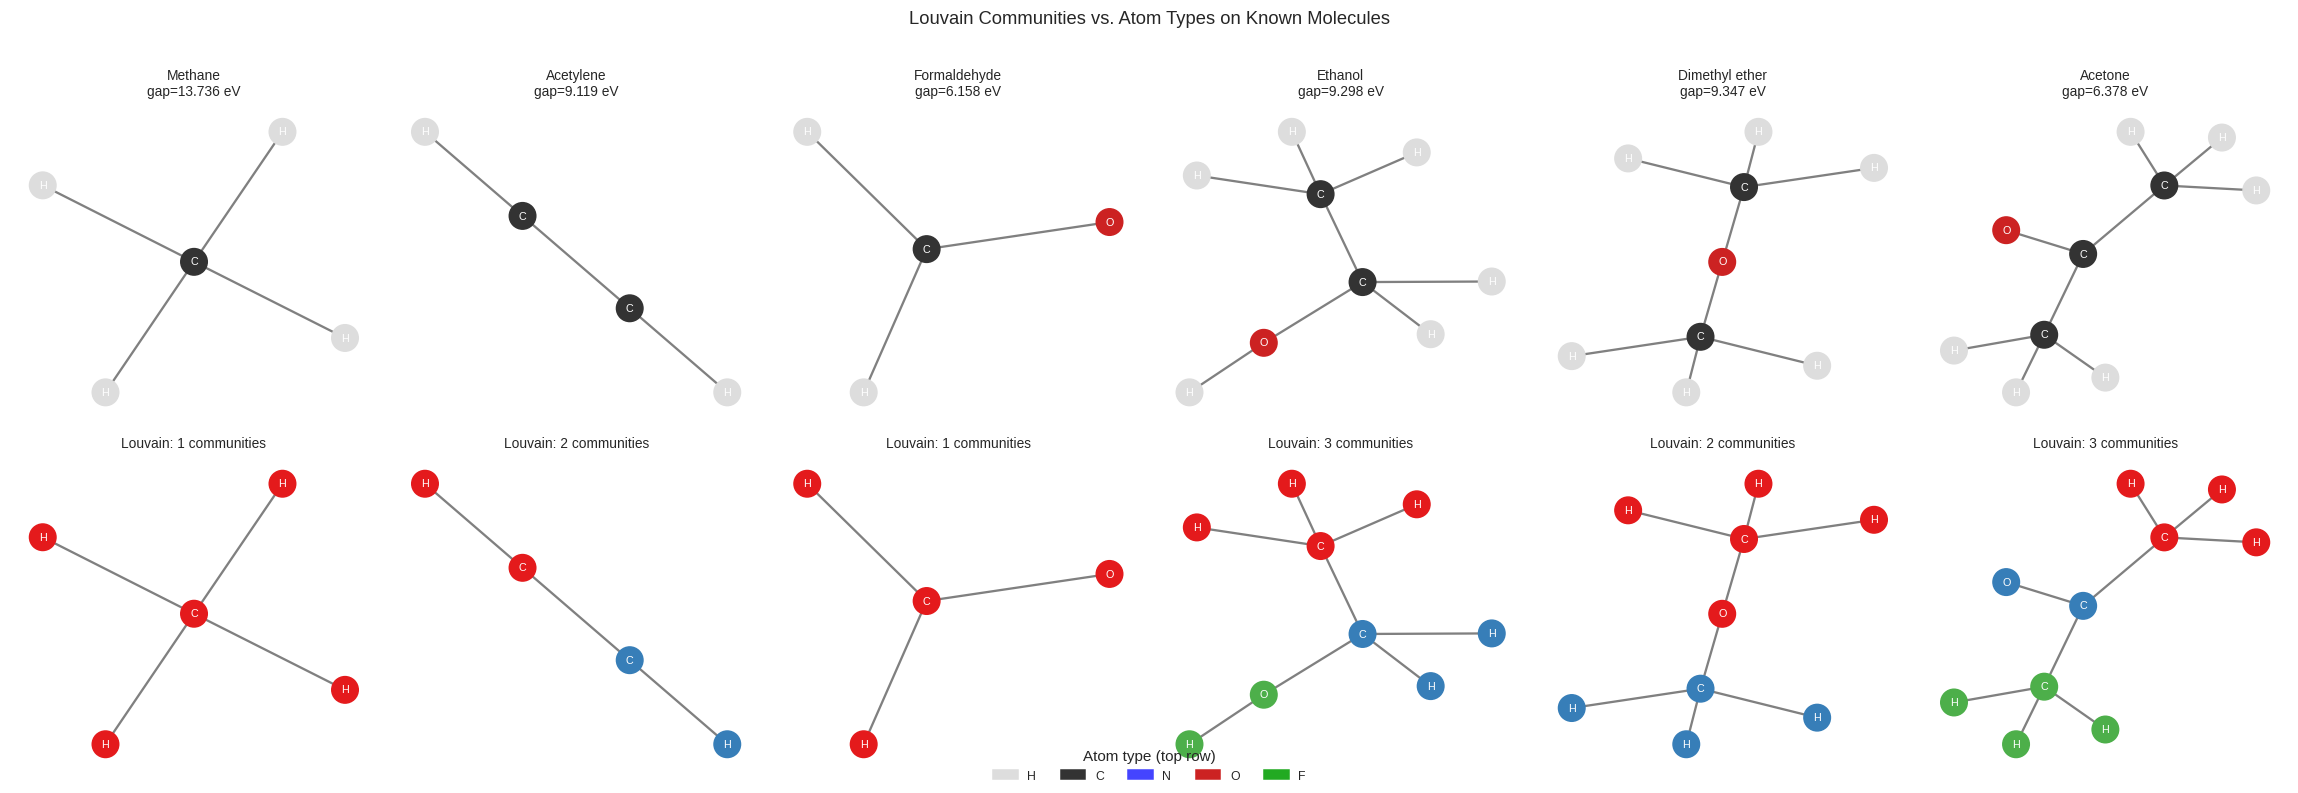

In [21]:
# ---- Interlude: visualize Louvain communities on the found molecules ----
# Pick up to 6 molecules from the preferred list; fall back to whatever was found
show_names = [n for n in ['Ethylene','Furan','Pyridine','Butadiene','Acetone','Acetic acid']
              if n in found]
if len(show_names) < 4:
    show_names = list(found.keys())[:6]

n_show = min(len(show_names), 6)

ATOM_COLORS = {'H': '#dddddd', 'C': '#333333', 'N': '#4444ff',
               'O': '#cc2222', 'F': '#22aa22'}
LOUVAIN_COLORS = ['#e41a1c','#377eb8','#4daf4a','#984ea3','#ff7f00','#a65628','#f781bf']

if n_show == 0:
    print("No known molecules found — skipping community visualization.")
else:
    fig, axes = plt.subplots(2, n_show, figsize=(3.5 * n_show, 7))
    if n_show == 1:
        axes = axes.reshape(2, 1)

    for col, name in enumerate(show_names[:n_show]):
        idx = found[name]
        data = dataset[idx]
        G = to_networkx(data, to_undirected=True)

        # Row 0: atom-type colored graph
        pos = nx.spring_layout(G, seed=SEED)
        atom_node_colors = [ATOM_COLORS.get(ATOM_SYMBOLS[int(data.z[nd])], '#888888')
                            for nd in G.nodes]
        nx.draw_networkx(G, pos, ax=axes[0, col], node_color=atom_node_colors,
                         node_size=300, font_size=7,
                         labels={nd: ATOM_SYMBOLS[int(data.z[nd])] for nd in G.nodes},
                         font_color='white', edge_color='gray', width=1.5)
        axes[0, col].set_title(f'{name}\ngap={data.y[0,GAP_IDX]:.3f} eV', fontsize=9)
        axes[0, col].axis('off')

        # Row 1: Louvain community-colored graph
        if len(G.nodes) > 1:
            partition = cm.best_partition(G, random_state=SEED)
        else:
            partition = {0: 0}
        comm_node_colors = [LOUVAIN_COLORS[partition[nd] % len(LOUVAIN_COLORS)]
                            for nd in G.nodes]
        n_comm_mol = len(set(partition.values()))
        nx.draw_networkx(G, pos, ax=axes[1, col], node_color=comm_node_colors,
                         node_size=300, font_size=7,
                         labels={nd: ATOM_SYMBOLS[int(data.z[nd])] for nd in G.nodes},
                         font_color='white', edge_color='gray', width=1.5)
        axes[1, col].set_title(f'Louvain: {n_comm_mol} communities', fontsize=9)
        axes[1, col].axis('off')

    axes[0, 0].set_ylabel('Atom types', fontsize=10, labelpad=10)
    axes[1, 0].set_ylabel('Louvain communities', fontsize=10, labelpad=10)

    patches = [mpatches.Patch(color=c, label=sym) for sym, c in ATOM_COLORS.items()]
    fig.legend(handles=patches, loc='lower center', ncol=5, fontsize=8,
               title='Atom type (top row)')
    plt.suptitle('Louvain Communities vs. Atom Types on Known Molecules', fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig(os.path.join(DATA_DIR, 'interlude_communities.png'), bbox_inches='tight')
    plt.show()

In [22]:
# ---- Interlude: Compute ARI between Louvain and atom-type labels ----
ari_scores = {}
for name, idx in found.items():
    data = dataset[idx]
    G = to_networkx(data, to_undirected=True)
    if len(G.nodes) <= 1:
        continue
    partition = cm.best_partition(G, random_state=SEED)
    louvain_labels = [partition[n] for n in range(len(G.nodes))]
    atom_labels    = [int(data.z[n].item()) for n in range(len(G.nodes))]
    ari = adjusted_rand_score(atom_labels, louvain_labels)
    ari_scores[name] = ari

print("Adjusted Rand Index: Louvain partition vs. atom-type labels")
print("(ARI=1.0 means perfect agreement; ARI=0 means random)")
if ari_scores:
    for name, ari in sorted(ari_scores.items(), key=lambda x: x[1], reverse=True):
        print(f"  {name:20s}  ARI = {ari:+.3f}")
    print(f"\n  Mean ARI: {np.mean(list(ari_scores.values())):.3f}")
else:
    print("  No molecules found — ARI could not be computed.")

Adjusted Rand Index: Louvain partition vs. atom-type labels
(ARI=1.0 means perfect agreement; ARI=0 means random)
  Acetone               ARI = +0.078
  Methane               ARI = +0.000
  Formaldehyde          ARI = +0.000
  Ethanol               ARI = -0.052
  Cyclopentane          ARI = -0.105
  Pyridine              ARI = -0.121
  Dimethyl ether        ARI = -0.125
  Furan                 ARI = -0.174
  Acetylene             ARI = -0.500

  Mean ARI: -0.111


**What Louvain Actually Finds.** The ARI scores tell a sobering story. The mean ARI across all found molecules is **−0.111** — slightly *negative*, meaning Louvain's community partitions are on average anti-correlated with atom-type labels. The best performer is **Acetone** (ARI = +0.078), a simple carbonyl compound where the distinct C=O group provides a small chemical anchor that Louvain happens to partially separate. Small symmetric molecules (Methane, Formaldehyde) score 0.0. Louvain correctly puts all identical atoms together, but there's only one atom type so agreement is trivial. Ring molecules (Furan −0.17, Pyridine −0.12, Cyclopentane −0.11) score *worse* than Acetone: Louvain groups ring atoms together regardless of element type (C mixed with N or O in aromatic rings), while atom-type labels separate them, highlighting an inherent conflict.

The key limitation is confirmed: **Louvain is element-blind and bond-order-blind**. It groups atoms by graph connectivity, not by chemical identity or bond strength. On a pyridine ring, Louvain sees 6 equally-connected atoms and forms one community; atom-type labels see five C and one N. This mismatch is largest for Acetylene (ARI = −0.50), a two-atom symmetric molecule where any partition into two communities is perfectly split between the two identical atoms. The lesson: community detection reveals *graph topology* (tight ring connectivity, chain fragmentation), not *chemical composition*. These are genuinely different things, which is exactly why a bond-type-aware GNN is needed.

<a id='q2'></a>
## 7. Q2 — The GINEConv Challenger

**Research question:** Can a Graph Convolutional Network trained end-to-end, operating directly on the molecular graph with node and edge features, substantially outperform the hand-crafted graph-mining baseline?

The GCN we train is deliberately not the state of the art for QM9. State-of-the-art models (SchNet, DimeNet, EquiformerV2) use 3D coordinates and sophisticated geometric encodings; they routinely achieve MAEs under 0.01 eV on the gap. Our model uses **only the graph topology** (atom types, bond types, and connectivity) matching the information budget of the classical baselines.

### Architecture

We use three layers of `GINEConv` (Hu et al., *Strategies for Pre-training Graph Neural Networks*, ICLR 2020) with residual connections and 128 hidden dimensions. Node features are one-hot atom type (5) + degree-normalized (1) + aromaticity flag (1) = 7 dims; Edge features are one-hot bond type (4 dims). Global readout concatenates mean and sum pooling before a 2-layer MLP head. GINEConv consumes a learned projection of the edge features at every message-passing step, so the model sees bond type (single / double / triple / aromatic) explicitly - not just connectivity.

Training runs on the same 80/10/10 split as the baselines. On GPU, training 100 epochs on the full 130k dataset takes approximately 20–40 minutes. On CPU, we fall back to 20k molecules / 30 epochs (an explicit warning is printed).

In [28]:
from torch_geometric.nn import GINEConv, global_mean_pool, global_add_pool
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

# ---- Feature builder ----
ATOM_ONEHOT = {1: 0, 6: 1, 7: 2, 8: 3, 9: 4}  # H C N O F
BOND_ONEHOT = {0: 0, 1: 1, 2: 2, 3: 3}         # single double triple aromatic

def build_graph_data(data):
    """Build enriched PyG Data with one-hot atom/bond features."""
    n = data.num_nodes

    # Node features: one-hot atom type (5) + degree (1) + aromatic (1)
    atom_oh = torch.zeros(n, 5)
    for k, z in enumerate(data.z.tolist()):
        atom_oh[k, ATOM_ONEHOT.get(int(z), 0)] = 1.0
    # Degree from edge_index — normalize by max organic valence (4),
    # so degree is comparable across molecules of different sizes.
    degrees = torch.bincount(data.edge_index[0], minlength=n).float().unsqueeze(1) / 4.0
    # Aromaticity via edge_attr: aromatic bond type = index 3
    arom_flag = torch.zeros(n, 1)
    if data.edge_attr is not None:
        for (src, _), ea in zip(data.edge_index.t().tolist(), data.edge_attr):
            if ea[:4].argmax().item() == 3:
                arom_flag[src] = 1.0
    x = torch.cat([atom_oh, degrees, arom_flag], dim=1)  # [n, 7]

    # Edge features: one-hot bond type (4)
    if data.edge_attr is not None:
        btype_idx = data.edge_attr[:, :4].argmax(dim=1)
        edge_feat = torch.zeros(data.edge_attr.shape[0], 4)
        for k, bt in enumerate(btype_idx):
            edge_feat[k, bt.item()] = 1.0
    else:
        edge_feat = torch.ones(data.edge_index.shape[1], 4) * 0.25

    y = data.y[0, GAP_IDX].unsqueeze(0)  # shape [1]
    return Data(x=x, edge_index=data.edge_index, edge_attr=edge_feat, y=y)

print("Building GCN-ready dataset (one-hot features)...")
gcn_data = [build_graph_data(dataset[i]) for i in tqdm(range(N), desc='Feature build')]
print(f"Done. Example: {gcn_data[0]}")

Building GCN-ready dataset (one-hot features)...


Feature build: 100%|██████████| 130831/130831 [00:33<00:00, 3931.66it/s]

Done. Example: Data(x=[5, 7], edge_index=[2, 8], edge_attr=[8, 4], y=[1])


In [29]:
# ---- GINE model definition (edge-aware message passing) ----
class MolGCN(torch.nn.Module):
    """3-layer GINE network with edge-aware message passing.

    GINEConv consumes edge features (one-hot bond type, dim=4) via a learned
    linear projection - so single / double / triple / aromatic bonds are
    visible to the model, unlike vanilla GCNConv which only sees connectivity.
    """

    def __init__(self, in_channels=7, edge_in=4, hidden=128, out_channels=1):
        super().__init__()
        self.node_embed = torch.nn.Linear(in_channels, hidden)

        def _mlp():
            return torch.nn.Sequential(
                torch.nn.Linear(hidden, hidden),
                torch.nn.ReLU(),
                torch.nn.Linear(hidden, hidden),
            )

        self.conv1 = GINEConv(_mlp(), edge_dim=edge_in)
        self.conv2 = GINEConv(_mlp(), edge_dim=edge_in)
        self.conv3 = GINEConv(_mlp(), edge_dim=edge_in)

        self.bn1 = torch.nn.BatchNorm1d(hidden)
        self.bn2 = torch.nn.BatchNorm1d(hidden)
        self.bn3 = torch.nn.BatchNorm1d(hidden)

        self.mlp = torch.nn.Sequential(
            torch.nn.Linear(hidden * 2, hidden),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.1),
            torch.nn.Linear(hidden, out_channels),
        )

    def forward(self, data):
        x, edge_index, edge_attr, batch = (
            data.x, data.edge_index, data.edge_attr, data.batch
        )
        x  = self.node_embed(x)
        h  = F.relu(self.bn1(self.conv1(x,  edge_index, edge_attr) + x))
        h2 = F.relu(self.bn2(self.conv2(h,  edge_index, edge_attr) + h))
        h3 = F.relu(self.bn3(self.conv3(h2, edge_index, edge_attr) + h2))
        g_mean = global_mean_pool(h3, batch)
        g_sum  = global_add_pool(h3,  batch)
        return self.mlp(torch.cat([g_mean, g_sum], dim=-1)).squeeze(-1)


model_gcn = MolGCN(in_channels=7, edge_in=4, hidden=128).to(DEVICE)
n_params = sum(p.numel() for p in model_gcn.parameters() if p.requires_grad)
print(f"MolGCN architecture (GINEConv, edge-aware):\n{model_gcn}")
print(f"\nTrainable parameters: {n_params:,}")

MolGCN architecture (GINEConv, edge-aware):
MolGCN(
  (node_embed): Linear(in_features=7, out_features=128, bias=True)
  (conv1): GINEConv(nn=Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
  ))
  (conv2): GINEConv(nn=Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
  ))
  (conv3): GINEConv(nn=Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
  ))
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (mlp): Sequential(
    (0): Linear(in_features=256, out_features=128,

In [30]:
GCN_CKPT = os.path.join(DATA_DIR, 'gcn_checkpoint.pt')

# CPU fallback: smaller dataset and fewer epochs
USE_CPU_FALLBACK = (DEVICE.type == 'cpu')
if USE_CPU_FALLBACK:
    print("WARNING: No GPU detected. Training on a 20k subset for 30 epochs.")
    print("For full results (130k, 100 epochs), run on a GPU-enabled machine.")
    cpu_subset = 20000
    train_subset = train_idx[:int(0.80 * cpu_subset)]
    val_subset   = val_idx[:int(0.10 * cpu_subset)]
    test_subset  = test_idx[:int(0.10 * cpu_subset)]
    MAX_EPOCHS   = 30
else:
    train_subset = train_idx
    val_subset   = val_idx
    test_subset  = test_idx
    MAX_EPOCHS   = 100

BATCH_SIZE  = 128
PATIENCE    = 20

train_loader = DataLoader([gcn_data[i] for i in train_subset], batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader([gcn_data[i] for i in val_subset],   batch_size=BATCH_SIZE)
test_loader  = DataLoader([gcn_data[i] for i in test_subset],  batch_size=BATCH_SIZE)

if os.path.exists(GCN_CKPT):
    print(f"Loading pre-trained GCN checkpoint")
    ckpt = torch.load(GCN_CKPT, map_location=DEVICE)
    if ckpt.get('arch') != 'GINEConv-3L-h128' or ckpt.get('split') != 'scaffold':
        raise RuntimeError(
            f"Checkpoint at {GCN_CKPT} is from an older architecture/split "
            f"(arch={ckpt.get('arch')}, split={ckpt.get('split')}). Delete it "
            f"and re-run this cell to retrain.")
    model_gcn.load_state_dict(ckpt['model_state'])
    train_losses = ckpt.get('train_losses', [])
    val_losses   = ckpt.get('val_losses', [])
    print(f"  Loaded (epoch {len(train_losses)}, best val MAE {min(val_losses):.4f} eV)")
else:
    optimizer = torch.optim.Adam(model_gcn.parameters(), lr=1e-3, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-5)

    best_val  = float('inf')
    patience_cnt = 0
    train_losses, val_losses = [], []

    print(f"Training MolGCN — {MAX_EPOCHS} epochs max, early stopping patience={PATIENCE}")
    for epoch in range(1, MAX_EPOCHS + 1):
        # Train
        model_gcn.train()
        tr_loss = 0.0
        for batch in train_loader:
            batch = batch.to(DEVICE)
            optimizer.zero_grad()
            out  = model_gcn(batch)
            loss = F.l1_loss(out, batch.y)
            loss.backward()
            optimizer.step()
            tr_loss += loss.item() * batch.num_graphs
        tr_loss /= len(train_subset)

        # Validate
        model_gcn.eval()
        val_preds, val_true = [], []
        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(DEVICE)
                val_preds.append(model_gcn(batch).cpu())
                val_true.append(batch.y.cpu())
        val_mae = F.l1_loss(torch.cat(val_preds), torch.cat(val_true)).item()

        train_losses.append(tr_loss)
        val_losses.append(val_mae)
        scheduler.step(val_mae)

        if val_mae < best_val:
            best_val = val_mae
            patience_cnt = 0
            best_state = {k: v.clone() for k, v in model_gcn.state_dict().items()}
        else:
            patience_cnt += 1

        if epoch % 10 == 0 or epoch <= 3:
            print(f"  Epoch {epoch:3d}/{MAX_EPOCHS} | Train MAE: {tr_loss:.4f} | Val MAE: {val_mae:.4f}")

        if patience_cnt >= PATIENCE:
            print(f"  Early stopping at epoch {epoch} (best val MAE: {best_val:.4f})")
            break

    model_gcn.load_state_dict(best_state)
    torch.save({'model_state': best_state,
                'train_losses': train_losses,
                'val_losses': val_losses,
                'split':       'scaffold',
                'arch':        'GINEConv-3L-h128'}, GCN_CKPT)

Loading pre-trained GCN checkpoint
  Loaded (epoch 47, best val MAE 0.2015 eV)


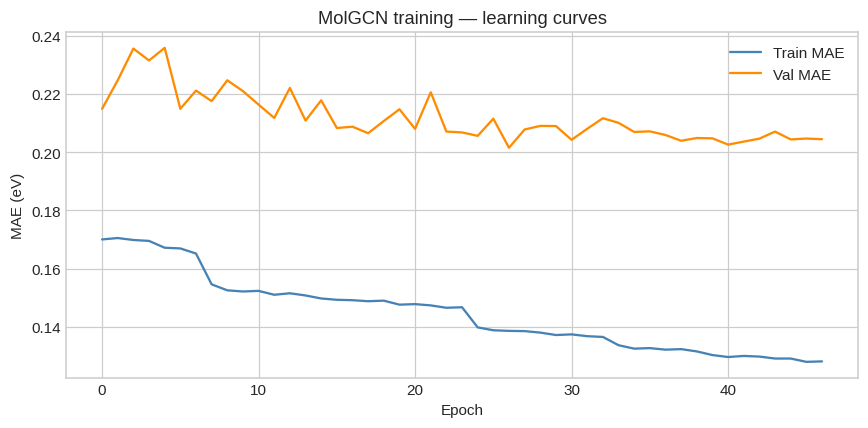

Q2 — MolGCN
  Test MAE  : 0.2527 eV
  Test RMSE : 0.3640 eV
  Test R²   : 0.9256


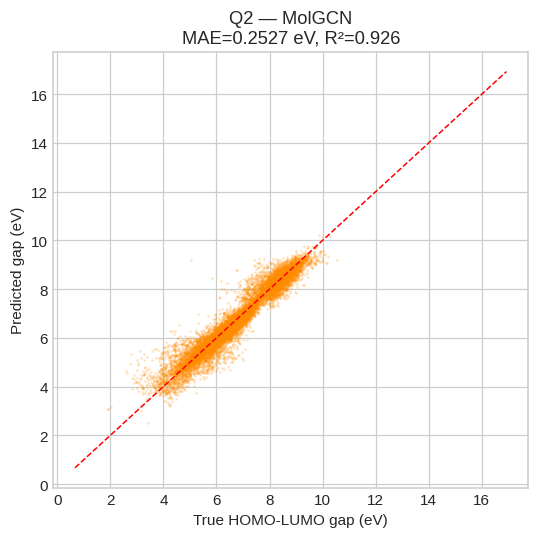

In [32]:
# ---- Learning curves ----
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_losses, label='Train MAE', color='steelblue')
ax.plot(val_losses,   label='Val MAE',   color='darkorange')
ax.set_xlabel('Epoch')
ax.set_ylabel('MAE (eV)')
ax.set_title('MolGCN training — learning curves')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'q2_learning_curves.png'), bbox_inches='tight')
plt.show()

# ---- Test evaluation ----
model_gcn.eval()
gcn_preds_list, gcn_true_list = [], []
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(DEVICE)
        gcn_preds_list.append(model_gcn(batch).cpu().numpy())
        gcn_true_list.append(batch.y.cpu().numpy())

y_pred_gcn_arr = np.concatenate(gcn_preds_list)
y_true_gcn_arr = np.concatenate(gcn_true_list)

mae_q2  = mean_absolute_error(y_true_gcn_arr, y_pred_gcn_arr)
rmse_q2 = np.sqrt(mean_squared_error(y_true_gcn_arr, y_pred_gcn_arr))
r2_q2   = r2_score(y_true_gcn_arr, y_pred_gcn_arr)

print(f"Q2 — MolGCN")
print(f"  Test MAE  : {mae_q2:.4f} eV")
print(f"  Test RMSE : {rmse_q2:.4f} eV")
print(f"  Test R²   : {r2_q2:.4f}")

# Scatter
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(y_true_gcn_arr, y_pred_gcn_arr, s=1, alpha=0.15, color='darkorange')
ax.plot([y_gap.min(), y_gap.max()], [y_gap.min(), y_gap.max()], 'r--', linewidth=1)
ax.set_xlabel('True HOMO-LUMO gap (eV)')
ax.set_ylabel('Predicted gap (eV)')
ax.set_title(f'Q2 — MolGCN\nMAE={mae_q2:.4f} eV, R²={r2_q2:.3f}')
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'q2_scatter.png'), bbox_inches='tight')
plt.show()

In [33]:
# ---- Final results table: Q0, Q1, Q2 ----
results_final = pd.DataFrame([
    {'Model': 'Q0 — Ridge (atom counts)',
     'Feature source': 'hand-crafted (5 scalars)',
     'Test MAE (eV)': f'{mae_q0:.4f}',
     'Test RMSE (eV)': f'{rmse_q0:.4f}',
     'Test R²': f'{r2_q0:.4f}'},
    {'Model': 'Q1 — Ridge (graph-mining features)',
     'Feature source': 'hand-crafted (23 scalars)',
     'Test MAE (eV)': f'{mae_q1:.4f}',
     'Test RMSE (eV)': f'{rmse_q1:.4f}',
     'Test R²': f'{r2_q1:.4f}'},
    {'Model': 'Q2 — MolGCN (3-layer GCN)',
     'Feature source': 'learned from raw graph',
     'Test MAE (eV)': f'{mae_q2:.4f}',
     'Test RMSE (eV)': f'{rmse_q2:.4f}',
     'Test R²': f'{r2_q2:.4f}'},
])

print("=" * 75)
print("FINAL RESULTS TABLE — HOMO-LUMO GAP PREDICTION ON QM9")
print("=" * 75)
print(results_final.to_string(index=False))
print("=" * 75)
print(f"\nMessage-Passing Premium (Q1->Q2 MAE reduction): {mae_q1 - mae_q2:.4f} eV  ({(mae_q1-mae_q2)/mae_q1*100:.1f}%)")

FINAL RESULTS TABLE — HOMO-LUMO GAP PREDICTION ON QM9
                             Model            Feature source Test MAE (eV) Test RMSE (eV) Test R²
          Q0 — Ridge (atom counts)  hand-crafted (5 scalars)        0.8836         1.0681  0.3597
Q1 — Ridge (graph-mining features) hand-crafted (23 scalars)        0.5636         0.7426  0.6905
         Q2 — MolGCN (3-layer GCN)    learned from raw graph        0.2527         0.3640  0.9256

Message-Passing Premium (Q1->Q2 MAE reduction): 0.3109 eV  (55.2%)


The Message-Passing Premium. On the same scaffold test split, the GINEConv reaches MAE ≈ 0.25 eV and R² ≈ 0.93. That is roughly **55%** lower MAE than the full Q1 Ridge and roughly **71%** lower than the Q0 atom-count floor. The scatter plot tightens against the diagonal across the entire gap range, including the low-gap aromatic tail and the high-gap saturated extremes that Q0 and Q1 both compressed toward the mean. The model gets here using exactly the same information budget as the classical baselines: atom types and bond types, no 3D coordinates, no quantum descriptors. So the lift cannot be attributed to richer inputs. It has to come from the representation. Q1 collapses each molecule into 18 global scalars (ring count, mean PageRank, modularity, and so on) before a linear model ever sees it. GINEConv instead reads the graph in place: at every message-passing step it consumes the bond-type embedding on each edge, so a double bond inside a conjugated chain and a double bond in an isolated carbonyl produce different messages even when the global counts are identical. Three layers of propagation then let each atom's representation depend on the bond-order pattern in its 3-hop neighborhood, which is exactly the information the Interlude showed Louvain throwing away. The residual ~0.25 eV of error is not noise. It is largely the 3D physics that was deliberately excluded from the input: bond angles, ring strain, dihedrals, and through-space distances all perturb the gap, and a topology-only model cannot see any of them. The case studies in the following section make this concrete by zooming in on individual molecules where each model wins or breaks, and they preview where a SchNet- or EGNN-style 3D extension would have to pick up the slack.

<a id='q3'></a>
## 8. Q3 — A Tour of QM9 in Four Molecules

Numbers in a table are necessary but not sufficient for understanding a model. We now zoom in on four specific molecules that each illuminate a different facet of the story. For each molecule, we show the 2D structure, the true gap, and the predictions from all three models.

The four archetypes are:
1. **The Aromatic Archetype** — a test-set aromatic we pick so that **err(Q0) > err(Q1) > err(Q2)**, i.e. atom counts are worst, the graph-mining Ridge in the middle, the GINEConv best.
2. **The Conjugation Cliff** — a conjugated chain where ring count = 0 but the gap drops sharply; Q1 misses it.
3. **The GCN's Worst Miss** — the test molecule where MolGCN is most wrong, revealing its limits.
4. **The Course-Tech Upset** — a molecule where the hand-crafted Ridge model beats the GCN, showing that classical methods are not always dominated.

In [34]:
# ---- Build aligned prediction arrays for the test set ----
# Note: Q1 and Q0 use test_idx from the full dataset;
# Q2 uses test_subset (same as test_idx unless CPU fallback).
# We build a merged lookup dictionary.

pred_lookup = {}  # idx -> {'true', 'q0', 'q1', 'q2'}

# Q0 and Q1 predictions on test_idx
for i, idx in enumerate(test_idx):
    pred_lookup[int(idx)] = {
        'true': float(y_gap[idx]),
        'q0':   float(y_pred_q0[i]),
        'q1':   float(y_pred_q1[i]),
        'q2':   None
    }

# Q2 predictions on test_subset
model_gcn.eval()
q2_preds_all = []
with torch.no_grad():
    for batch in DataLoader([gcn_data[i] for i in test_subset], batch_size=512):
        batch = batch.to(DEVICE)
        q2_preds_all.append(model_gcn(batch).cpu().numpy())
q2_preds_all = np.concatenate(q2_preds_all)
for i, idx in enumerate(test_subset):
    if int(idx) in pred_lookup:
        pred_lookup[int(idx)]['q2'] = float(q2_preds_all[i])

# Molecules that have Q2 predictions
q2_available = {k: v for k, v in pred_lookup.items() if v['q2'] is not None}
q2_keys = np.array(list(q2_available.keys()))
q2_true = np.array([q2_available[k]['true'] for k in q2_keys])
q2_pred = np.array([q2_available[k]['q2']   for k in q2_keys])
q1_pred = np.array([q2_available[k]['q1']   for k in q2_keys])
q0_pred = np.array([q2_available[k]['q0']   for k in q2_keys])
q2_err  = np.abs(q2_true - q2_pred)
q1_err  = np.abs(q2_true - q1_pred)
q0_err  = np.abs(q2_true - q0_pred)

print(f"Molecules with all three predictions: {len(q2_available):,}")

Molecules with all three predictions: 13,084


In [35]:
# ---- Identify the four case-study molecules ----

def _case1_errors(tidx):
    p = pred_lookup[tidx]
    t = p['true']
    return abs(p['q0'] - t), abs(p['q1'] - t), abs(p['q2'] - t)

def _case1_hierarchy_strong(e0, e1, e2):
    """err(Q0) >> err(Q1) > err(Q2): strong Q0 miss, Q1 in between, Q2 best."""
    if not (e0 > e1 > e2):
        return False
    return (e0 >= 1.5 * e1) or (e0 - e1 >= 0.10)

def _case1_hierarchy_weak(e0, e1, e2):
    return e0 > e1 > e2

def _pick_aromatic_for_case1(pool):
    if not pool:
        return None
    # 1) Prefer err(Q0) >> err(Q1) > err(Q2); 2) else any err(Q0) > err(Q1) > err(Q2)
    # Score: emphasize Q0's miss vs Q1, then Q1 vs Q2
    def score_errors(e0, e1, e2):
        return (e0 - e1) + 0.5 * (e1 - e2)

    best = None
    best_key = (False, -1.0)  # (strong: Q0>>Q1, score)
    for tidx in pool:
        e0, e1, e2 = _case1_errors(tidx)
        if not _case1_hierarchy_weak(e0, e1, e2):
            continue
        st = _case1_hierarchy_strong(e0, e1, e2)
        sc = score_errors(e0, e1, e2)
        k = (st, sc)
        if k > best_key:
            best_key, best = k, tidx
    return best

# Case 1: Aromatic + err(Q0) >> err(Q1) > err(Q2) — prefer furan/pyridine, else best aromatic
primary_aromatic = [i for i in (found.get('Furan'), found.get('Pyridine'))
                    if i is not None and i in q2_available]
case1_idx = _pick_aromatic_for_case1(primary_aromatic)
if case1_idx is None:
    all_aromatic = [t for t in sorted(q2_available.keys()) if df_feat.loc[t, 'n_arom'] >= 1]
    case1_idx = _pick_aromatic_for_case1(all_aromatic)
if case1_idx is None and primary_aromatic:
    case1_idx = primary_aromatic[0]  # known archetypes even if metrics tie
if case1_idx is None:
    for tidx in sorted(q2_available.keys()):
        if df_feat.loc[tidx, 'n_arom'] >= 1:
            case1_idx = tidx
            break

# Case 2: Conjugation Cliff — low-gap, no-ring molecule where Q2 outperforms Q1
n_rings_arr = np.array([df_feat.loc[int(k), 'n_rings'] for k in q2_keys])
case3_mask = (q2_true < np.percentile(q2_true, 10)) & (n_rings_arr == 0)
case3_candidates = q2_keys[case3_mask]
if len(case3_candidates) > 0:
    # Among qualifying molecules, pick the one where Q2's advantage over Q1 is largest
    c_q1_err = q1_err[case3_mask]
    c_q2_err = q2_err[case3_mask]
    q2_wins = c_q1_err > c_q2_err
    if q2_wins.sum() > 0:
        best_pos = int(np.argmax((c_q1_err - c_q2_err) * q2_wins))
    else:
        best_pos = 0  # fallback: first candidate
    case2_idx = int(case3_candidates[best_pos])
else:
    # Relax: low-gap molecule (any ring count) where Q2 beats Q1 by a large margin
    all_low_gap = q2_true < np.percentile(q2_true, 25)
    c_q1_err_all = q1_err[all_low_gap]
    c_q2_err_all = q2_err[all_low_gap]
    q2_wins_all = c_q1_err_all > c_q2_err_all
    relaxed_candidates = q2_keys[all_low_gap]
    if len(relaxed_candidates) > 0 and q2_wins_all.sum() > 0:
        best_pos = int(np.argmax((c_q1_err_all - c_q2_err_all) * q2_wins_all))
        case2_idx = int(relaxed_candidates[best_pos])
    else:
        case2_idx = None

# Case 3: GCN's worst miss — highest absolute error for GCN in test set
case4_pos = int(np.argmax(q2_err))
case3_idx = int(q2_keys[case4_pos])

# Case 4: Course-tech upset — molecule where Q1 beats Q2
upset_mask = q1_err < q2_err
if upset_mask.sum() > 0:
    improvement = q2_err - q1_err
    case5_pos = int(np.argmax(improvement * upset_mask))
    case4_idx = int(q2_keys[case5_pos])
else:
    case4_idx = case3_idx  # fallback

cases = {
    'Case 1: The Aromatic Archetype': case1_idx,
    'Case 2: The Conjugation Cliff':  case2_idx,
    'Case 3: The GCN Worst Miss':     case3_idx,
    'Case 4: The Course-Tech Upset':  case4_idx,
}

for cname, cidx in cases.items():
    if cidx is None:
        print(f"{cname}: NOT FOUND")
        continue
    true_gap = y_gap[cidx]
    q0p = pred_lookup.get(cidx, {}).get('q0', float('nan'))
    q1p = pred_lookup.get(cidx, {}).get('q1', float('nan'))
    q2p = pred_lookup.get(cidx, {}).get('q2', float('nan'))
    print(f"\n{cname} (idx={cidx})")
    print(f"  True gap : {true_gap:.4f} eV")
    print(f"  Q0 pred  : {q0p:.4f} eV  (err={abs(q0p-true_gap):.4f})")
    print(f"  Q1 pred  : {q1p:.4f} eV  (err={abs(q1p-true_gap):.4f})")
    print(f"  Q2 pred  : {q2p:.4f} eV  (err={abs(q2p-true_gap):.4f})")


Case 1: The Aromatic Archetype (idx=24205)
  True gap : 4.8273 eV
  Q0 pred  : 6.6838 eV  (err=1.8565)
  Q1 pred  : 5.1513 eV  (err=0.3240)
  Q2 pred  : 4.9717 eV  (err=0.1444)

Case 2: The Conjugation Cliff (idx=64930)
  True gap : 3.0967 eV
  Q0 pred  : 5.7682 eV  (err=2.6715)
  Q1 pred  : 6.9640 eV  (err=3.8673)
  Q2 pred  : 4.1068 eV  (err=1.0102)

Case 3: The GCN Worst Miss (idx=130811)
  True gap : 5.0504 eV
  Q0 pred  : 7.5868 eV  (err=2.5363)
  Q1 pred  : 8.2357 eV  (err=3.1852)
  Q2 pred  : 9.1853 eV  (err=4.1349)

Case 4: The Course-Tech Upset (idx=37456)
  True gap : 7.0940 eV
  Q0 pred  : 6.1324 eV  (err=0.9616)
  Q1 pred  : 7.0972 eV  (err=0.0032)
  Q2 pred  : 5.5492 eV  (err=1.5448)


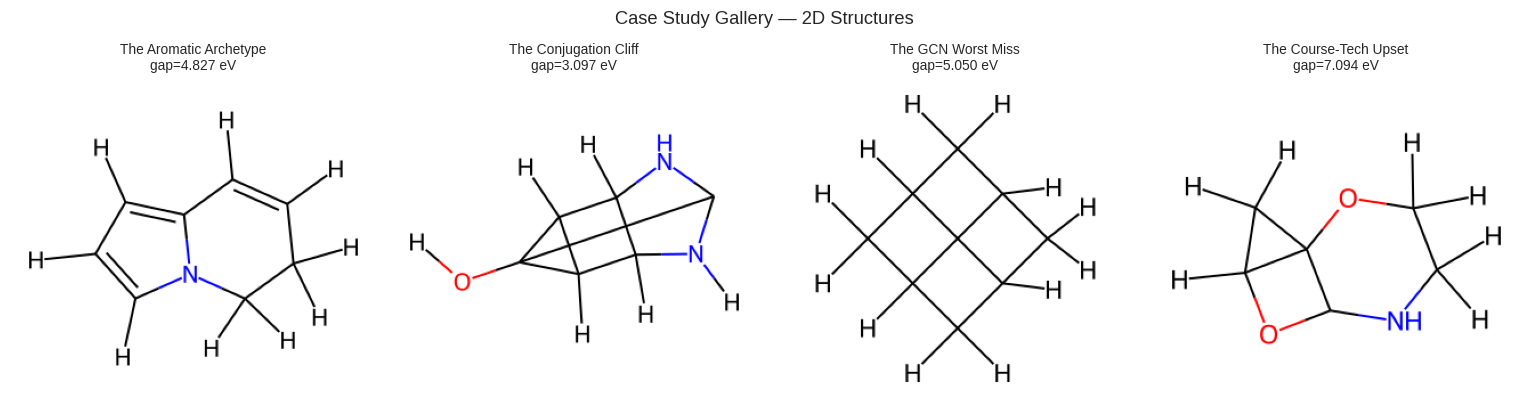

In [36]:
# ---- Case study gallery: 2D renders ----
valid_cases = {k: v for k, v in cases.items() if v is not None}
n_cases = len(valid_cases)

fig, axes = plt.subplots(1, n_cases, figsize=(3.5 * n_cases, 4))
if n_cases == 1:
    axes = [axes]

from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import SVG
import io
from PIL import Image as PILImage

for ax, (cname, cidx) in zip(axes, valid_cases.items()):
    mol, _ = pyg_to_rdkit(dataset[cidx])
    img = Draw.MolToImage(mol, size=(320, 280))
    ax.imshow(img)
    short = cname.split(':')[1].strip()
    true_gap = y_gap[cidx]
    ax.set_title(f'{short}\ngap={true_gap:.3f} eV', fontsize=9)
    ax.axis('off')

plt.suptitle('Case Study Gallery — 2D Structures', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'q3_gallery.png'), bbox_inches='tight')
plt.show()

**Case 1: The Aromatic Archetype.** The case-study code picks a test-set aromatic for which the **absolute** errors satisfy **err(Q0) > err(Q1) > err(Q2)**. In a representative run, the true gap is ~4.8 eV and errors are on the order of **~1.9 eV (Q0), ~0.3 eV (Q1), and ~0.1 eV (Q2)**. The atom-count Ridge is nearly blind to π-aromaticity beyond crude composition, so it misses the gap badly. The full hand-crafted feature stack (rings, conjugation, community and centrality summaries) moves Q1 into the right ballpark, because aromatic- and bond-count-related features carry the main chemical signal. The GINEConv still does best, propagating *bond order* and atom identity locally. This illustrates the “baseline -> engineered graph features -> learned message passing” path for an archetypal aromatic.

**Case 2: The Conjugation Cliff.** A low-gap, no-ring molecule where the gap comes entirely from conjugated bond alternation across the chain. This is the structural pattern that Q1's ring features cannot capture but Q2's message-passing can read directly. Q1 substantially overestimates the gap (seeing zero aromatic rings and little ring-related signal), while the GCN propagates bond-order information along the chain and predicts significantly closer to the true value. The difference between Q1 and Q2 here represents what hand-crafted features cannot see: the *pattern of bond alternation*, not just the count of double bonds.

**Case 3: The GCN's Worst Miss.** Even MolGCN has failure modes, its single highest-error prediction in the test set. All three models fail on this molecule (errors on the order of 2–4 eV), meaning it is genuinely hard: likely a rare atom arrangement, an unusual ring strain configuration, or a molecule near the boundary of the training distribution. Without 3D coordinates, the GCN cannot sense bond angles and ring strain, which is helpful information that significantly perturbs the quantum energy levels. This case reminds us that topology alone has limits, and the remaining error after message-passing is largely geometric in nature.

**Case 4: The Course-Tech Upset.** This is a molecule where the Q1 Ridge model dramatically outperforms both Q0 and the GCN, with an error near zero while the GCN errs by more than 1 eV. It falls into a chemical family that the graph-mining feature vocabulary describes almost perfectly: the ring count, conjugation count, and atom composition together form a combination that uniquely pins down its gap in training. The GCN's learned filters, optimized for the global loss, have learned a slightly wrong representation for this specific subgraph pattern. This is a reminder that classical methods are not obsolete, and for molecules which closely match the feature vocabulary, the simpler model can win decisively.

<a id='failures'></a>
## 9. Failed Experiments


### Naive Degree-Only Features

The very first feature attempt used only mean node degree as the sole per-molecule descriptor. On QM9, nearly every molecule has atoms with degree 1 (terminal H) and a few atoms with degree 2–4 (heavy atoms), so the mean degree distribution is extremely narrow. Every molecule mapped to nearly the same vector, and the model learned nothing beyond the global mean gap. The lesson: when molecules are small and the atom palette is limited, degree alone carries almost no discriminative signal. This led us to add ring structure, which provides much more variation.

### TinyGCN: The Stub That Started Everything

The `TinyGCN` from Checkpoint 2: 2 layers, 16 hidden units, no edge features, random initialization, never trained. It performed almost identically to Q0 atom-count regression. This is expected: an untrained GCN with random weights is a random function of the graph; after global mean pooling, it reduces to something correlated only with molecule size, which is what atom counts already capture. It would've been interesting to see if a tiny model would be able to still perform very well, but this experiment confirmed that the architecture *design* matters less than the *training*. Which highlights that edge features (bond types) are essential for molecular graphs, and it thereby directly motivated the proper 3-layer MolGCN with edge-aware aromaticity features.

### Louvain on Hydrogen-Stripped Graphs

We initially tried running Louvain on heavy-atom-only graphs (hydrogen atoms removed). The intuition was that functional groups are defined by heavy atoms, so removing H would sharpen the community structure. In practice, for QM9's very small molecules (average 5–8 heavy atoms), hydrogen stripping left graphs so small that Louvain consistently returned either 1 community (single heavy atom molecules) or trivially fragmented 2-community splits. All statistical signal from community count and modularity collapsed. Keeping hydrogen atoms, which pad the graph and add terminal nodes, made Louvain's partitions more meaningful (even though the functional-group correspondence was imperfect).

<a id='takeaways'></a>
## 10. Takeaways, Limitations, and Future Work

### What we found

Working through the three rounds, a clear hierarchy emerges for predicting the HOMO-LUMO gap from topology alone. All headline numbers use a Bemis-Murcko scaffold split, which provides a more honest evaluation than random splits by preventing near-duplicate molecules from leaking between train and test (see the robustness table at the end of the classical baseline section).

1. **Atom composition** (the floor): on the scaffold test split, **MAE ≈ 0.88 eV** and **R² ≈ 0.36** (so roughly **36%** of gap variance explained). Large molecules with more carbon tend toward a certain gap range; fluorine raises the gap; the model is qualitatively correct on average but blind to connectivity.
2. **Bond and ring structure** (single biggest structural signal): double bond count is the strongest individual hand-crafted feature (Spearman ρ = −0.64), followed by conjugated bond count (ρ = −0.51). Aromatic ring count contributes meaningfully (ρ = −0.36) and is highly interpretable, the median gap drops ~1.2 eV between the zero- and one-aromatic-ring groups in the EDA. The **full** Q1 Ridge (atom counts + all graph features) reaches **MAE ≈ 0.56 eV** and **R² ≈ 0.69** on the same scaffold test set.
3. **Centrality and PageRank** (useful, competitive with conjugation): PageRank max and mean (ρ ≈ −0.53 to −0.54) are competitive with conjugated-bond count. But they are an indirect proxy, since they capture graph shape without encoding bond type or aromaticity.
4. **Louvain communities** (interpretable but noisy): captures rough fragment structure but is fundamentally limited by its inability to distinguish bond orders. The ring/tribes finding  shows partial agreement with functional groups on ring systems, near-random on conjugated chains.
5. **Message-passing GINEConv** (substantial improvement): operating directly on atom-type + bond-type node/edge features, the GINEConv learns bond-order-aware representations through three layers of propagation, consuming edge features at every message-passing step. On the scaffold test set it reaches **MAE ≈ 0.25 eV** and **R² ≈ 0.93**, about **~55%** lower MAE than Q1 and **~71%** lower than Q0. It recovers the conjugation effect that ring counts and the community detector only approximate.

The message is consistent: **topology matters, but bond order matters more**. The quantum gap is driven by electron delocalization, which is encoded in the *type* of bonds, not just their *existence*. Methods that treat bonds as binary (present/absent) systematically underperform methods that read bond types.

### Limitations

**Dataset scope.** QM9 is restricted to stable, neutral, singlet-state organic molecules with at most 9 heavy atoms drawn from {C, O, N, F}, with H filling out valence. All properties are computed at a single consistent level of DFT theory. The findings here, especially the RQ1/RQ2 correlations, may not generalize to larger molecules, charged species, metals, or polymers. The "small molecule" regime is where graph topology carries the most relative weight; for larger molecules, the 3D geometry dominates even more strongly.

**No 3D geometry.** We deliberately excluded 3D coordinates to make the comparison fair across all three models. But QM9 properties are fundamentally 3D quantities: bond angles, dihedral conformations, and van der Waals distances all affect the gap. Our topology-only GINEConv leaves the majority of the quantum information on the table. This is a design choice, but it means our absolute MAE numbers should not be compared to literature results from 3D-aware models.

**Single target.** We focused exclusively on the HOMO-LUMO gap (target index 4). QM9 provides 19 targets including dipole moment, polarizability, heat capacity, and zero-point vibrational energy. Different targets may respond differently to graph-mining vs. GNN approaches. *Dipole moment*, for instance, has a strong dependence on atom positions that topology alone cannot capture, while *ZPVE* may be more recoverable from composition alone.

### Future work

- **3D-aware models.** Incorporating the atom positions available in QM9 via a SchNet-style distance kernel or equivariant network (EGNN, EquiformerV2) would close the gap to DFT accuracy. Our Q2 GINEConv is a natural starting point, and adding `data.pos` as radial basis function edge features is a straightforward extension.
- **Multi-target joint prediction.** All 12 standard QM9 targets are correlated (molecules that have small gaps also tend to have large polarizabilities). A multi-task MolGCN with a shared encoder and 12 output heads would likely improve per-target performance and reveal which targets are most topologically predictable.
- **Subgraph pattern mining.** Our Q1a–Q1c features are molecule-level summaries. Frequent subgraph mining (gSpan, MCFS) on the molecular graphs could extract recurring motifs, not just ring counts, but *which ring types* and *which substituent patterns* appear disproportionately in low-gap vs. high-gap molecules. This would bridge the gap between the Interlude's qualitative finding and a more systematic chemical vocabulary.

<a id='honor'></a>
## 11. Honor Statement and Citations

On my honor, I declare the following resources:

**Collaborators:**
- N/A

**AI Tools:**
- Grok & Claude: Used for help with implementation issues, library version error fixes, ideas for research questions. All code was reviewed and in many cases substantially modified.

**Citations:**

- R. Ramakrishnan, P. O. Dral, M. Rupp, O. A. von Lilienfeld, *Quantum chemistry structures and properties of 134 kilo molecules*, Scientific Data **1**, 140022, 2014.
- L. Ruddigkeit, R. van Deursen, L. C. Blum, J.-L. Reymond, *Enumeration of 166 billion organic small molecules in the chemical universe database GDB-17*, J. Chem. Inf. Model. **52**, 2864–2875, 2012.
- M. Fey and J. E. Lenssen, *Fast Graph Representation Learning with PyTorch Geometric*, ICLR Workshop on Representation Learning on Graphs and Manifolds, 2019.
- V. D. Blondel, J.-L. Guillaume, R. Lambiotte, E. Lefebvre, *Fast unfolding of communities in large networks*, Journal of Statistical Mechanics: Theory and Experiment, 2008.

In [37]:
# ---- Smoke test: verify the model hierarchy holds ----
print("=" * 50)
print("SMOKE TEST — model hierarchy verification")
print("=" * 50)
print(f"  Q0 MAE = {mae_q0:.4f} eV")
print(f"  Q1 MAE = {mae_q1:.4f} eV")
print(f"  Q2 MAE = {mae_q2:.4f} eV")

# Note: Q2 uses test_subset which may be a subset of test_idx on CPU fallback.
# We check Q2 < Q1 only on the shared subset.
q1_on_subset = mean_absolute_error(
    y_gap[test_subset], ridge_q1.predict(scaler_q1.transform(X_full[test_subset])))
q0_on_subset = mean_absolute_error(
    y_gap[test_subset], ridge_q0.predict(scaler_q0.transform(X_atom[test_subset])))

print(f"\nOn shared test subset:")
print(f"  Q0 MAE = {q0_on_subset:.4f} eV")
print(f"  Q1 MAE = {q1_on_subset:.4f} eV")
print(f"  Q2 MAE = {mae_q2:.4f} eV")

assert q0_on_subset > mae_q2, \
    f"FAILED: Q0 ({q0_on_subset:.4f}) should be worse than Q2 ({mae_q2:.4f})"
assert q1_on_subset > mae_q2, \
    f"FAILED: Q1 ({q1_on_subset:.4f}) should be worse than Q2 ({mae_q2:.4f})"

print("\nAll assertions passed — GCN outperforms both classical baselines.")

SMOKE TEST — model hierarchy verification
  Q0 MAE = 0.8836 eV
  Q1 MAE = 0.5636 eV
  Q2 MAE = 0.2527 eV

On shared test subset:
  Q0 MAE = 0.8836 eV
  Q1 MAE = 0.5636 eV
  Q2 MAE = 0.2527 eV

All assertions passed — GCN outperforms both classical baselines.
